# Anomaly Classifier — CICIDS2017

## Descrição do Projeto
Pipeline de detecção de anomalias em tráfego de rede com base no dataset CICIDS2017.  
O pipeline combina pseudo-labelling não supervisionado (Isolation Forest (IF) + Local Outlier 
Factor (LOF), com consenso ponderado) com classificação supervisionada (Random Forest (RF) + 
Logistic Regression (LR)), avaliado com ground truth real e split temporal 80/20.

---

## 1. Imports
Carregamento de todas as bibliotecas necessárias ao longo do pipeline.

In [38]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
from matplotlib_venn import venn2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from matplotlib.patches import FancyArrowPatch
from numpy.polynomial import polynomial as P
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Imports concluídos")

Imports concluídos


## 2. Configuração Global
Definição dos paths para os ficheiros de dados e configuração do estilo visual 
aplicado globalmente a todos os gráficos do notebook + verificação de ficheiros.

In [39]:
# --- Paths ---
DATA_PATH = "../Dataset/"

FILES = {
    'Monday'    : 'Monday-WorkingHours.pcap_ISCX.csv',
    'Wednesday' : 'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday'  : 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Friday'    : 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
}

# --- Estilo global ---
BG_COLOR    = '#1a2233'
GRID_COLOR  = '#2e3f5c'
TEXT_COLOR  = '#d0d8e8'
BLUE        = '#5b8dd9'   # Normal
RED         = '#c0504d'   # Anómalo
GREEN       = '#2ea84f'   # Desejável
ORANGE      = '#f0a500'   # Moderado

plt.rcParams.update({
    'figure.facecolor'  :  BG_COLOR,
    'axes.facecolor'    :  BG_COLOR,
    'axes.edgecolor'    :  GRID_COLOR,
    'axes.labelcolor'   :  TEXT_COLOR,
    'axes.titlecolor'   :  TEXT_COLOR,
    'axes.spines.top'   :  False,
    'axes.spines.right' :  False,
    'axes.spines.left'  :  False,
    'axes.spines.bottom':  False,
    'xtick.color'       :  TEXT_COLOR,
    'ytick.color'       :  TEXT_COLOR,
    'text.color'        :  TEXT_COLOR,
    'grid.color'        :  '#ffffff',
    'grid.alpha'        :  0.12,
    'grid.linewidth'    :  0.7,
    'axes.grid'         :  True,
    'legend.frameon'    :  False,
    'legend.labelcolor' :  TEXT_COLOR,
    'font.family'       :  'sans-serif',
    'axes.titlesize'    :  13,
    'axes.titleweight'  :  'bold',
    'axes.labelsize'    :  11,
    'figure.titlesize'  :  15,
    'figure.titleweight':  'bold',
})

unidades_features = {
    'Flow Duration': 'μs',
    'Total Fwd Packets': 'pacotes',
    'Total Backward Packets': 'pacotes',
    'Total Length of Fwd Packets': 'bytes',
    'Total Length of Bwd Packets': 'bytes',
    'Flow Bytes/s': 'bytes/s',
    'Flow Packets/s': 'pacotes/s',
    'Fwd Packets/s': 'pacotes/s',
    'Bwd Packets/s': 'pacotes/s',
    'Flow IAT Mean': 'μs',
    'Flow IAT Std': 'μs',
    'Flow IAT Max': 'μs',
    'Flow IAT Min': 'μs',
    'Packet Length Mean': 'bytes',
    'Packet Length Std': 'bytes',
    'Min Packet Length': 'bytes',
    'Max Packet Length': 'bytes',
}

# Verificar ficheiros
print("=== VERIFICAÇÃO DE FICHEIROS ===")
for nome, ficheiro in FILES.items():
    path = os.path.join(DATA_PATH, ficheiro)
    existe = os.path.exists(path)
    tamanho = f"{os.path.getsize(path) / 1e6:.1f} MB" if existe else "NÃO ENCONTRADO"
    print(f"  {'✓' if existe else '✗'} {nome}: {tamanho}")

=== VERIFICAÇÃO DE FICHEIROS ===
  ✓ Monday: 176.9 MB
  ✓ Wednesday: 225.2 MB
  ✓ Thursday: 52.0 MB
  ✓ Friday: 58.3 MB


## 3. Carregamento dos Dados
Carregamento e concatenação dos 4 ficheiros CSV do CICIDS2017.  
Cada ficheiro corresponde a um dia de captura com tráfego normal e ataques distintos.  
É adicionada uma coluna `day` para identificar a origem de cada registo.

In [40]:
dfs = []

for nome, ficheiro in FILES.items():
    path = os.path.join(DATA_PATH, ficheiro)
    df_temp = pd.read_csv(path, encoding='utf-8', low_memory=False)
    df_temp['day'] = nome
    dfs.append(df_temp)
    print(f" {nome:<12} {df_temp.shape[0]:>9,} registos | {df_temp.shape[1]} colunas")

df = pd.concat(dfs, ignore_index=True)
total_bruto = df.shape[0]

print(f"\n=== DATASET COMBINADO ===")
print(f"  Total bruto       : {total_bruto:,}")
print(f"  Total de colunas  : {df.shape[1]}")
print(f"\n=== PRIMEIRAS LINHAS ===")
df.head()

 Monday         529,918 registos | 80 colunas
 Wednesday      692,703 registos | 80 colunas
 Thursday       170,366 registos | 80 colunas
 Friday         191,033 registos | 80 colunas

=== DATASET COMBINADO ===
  Total bruto       : 1,584,020
  Total de colunas  : 80

=== PRIMEIRAS LINHAS ===


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,day
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4,4,4,4.0000,0.0000,4,4,0,0.0000,0.0000,0,0,0,0,0,0,40,0,500000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
3,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
4,49486,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday


## 4. Limpeza dos Dados
Tratamento dos problemas conhecidos do CICIDS2017:
- Remoção de espaços nos nomes das colunas
- Conversão de valores `Infinity` para `NaN`
- Remoção de registos com `NaN`
- Conversão de tipos numéricos
- Limpeza e standardização da coluna `Label`

In [41]:
# Normalizar nomes das colunas
df.columns = df.columns.str.strip()

total_antes = df.shape[0]  # antes de qualquer alteração

print("=== ANTES DA LIMPEZA ===")
print(f"  Registos      : {df.shape[0]:,}")
print(f"  Colunas       : {df.shape[1]}")
print(f"  Valores NaN   : {df.isnull().sum().sum():,}")
print(f"  Valores Inf   : {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}")

# Substituir Infinity por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remover registos com NaN
df.dropna(inplace=True)

print(f"\n=== APÓS LIMPEZA ===")
print(f"  Registos            : {df.shape[0]:,}")
print(f"  Colunas             : {df.shape[1]}")
print(f"  Valores NaN         : {df.isnull().sum().sum():,}")
print(f"  Valores Inf         : {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}")
print(f"  Registos eliminados : {total_antes - df.shape[0]:,}")

=== ANTES DA LIMPEZA ===
  Registos      : 1,584,020
  Colunas       : 80
  Valores NaN   : 1,120
  Valores Inf   : 2,862

=== APÓS LIMPEZA ===
  Registos            : 1,582,029
  Colunas             : 80
  Valores NaN         : 0
  Valores Inf         : 0
  Registos eliminados : 1,991


## 5. Encoding da Label e Selecção de Features
Conversão da label textual para binário: `BENIGN=0`, qualquer ataque `=1`.  
Selecção das colunas relevantes para o pipeline, removendo colunas redundantes,  
de baixa variância, ou sem valor discriminativo.

In [42]:
# Encoding binário da label
df['label'] = (df['Label'] != 'BENIGN').astype(int)

print("=== DISTRIBUIÇÃO BINÁRIA ===")
print(df['label'].value_counts())
print(f"\n  % Anómalo : {df['label'].mean()*100:.2f}%")
print(f"  % Normal  : {(1-df['label'].mean())*100:.2f}%")

# Colunas a remover:
# - Label original (substituída por label binária)
# - Colunas com variância zero
# - Colunas de ID sem valor preditivo

# Identificar colunas de variância zero
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
zero_var = [col for col in numeric_cols if df[col].var() == 0]

print(f"\n=== COLUNAS VARIÂNCIA ZERO ({len(zero_var)}) ===")
print(zero_var)

# Remover Label original e colunas variância zero
cols_remover = ['Label'] + zero_var
df.drop(columns=cols_remover, inplace=True)

print(f"\n=== COLUNAS APÓS SELECÇÃO ===")
print(f"  Total : {df.shape[1]}")
colunas = df.columns.tolist()
for i in range(0, len(colunas), 10):
    print(f"  {colunas[i:i+10]}")

=== DISTRIBUIÇÃO BINÁRIA ===
label
0    1326170
1     255859
Name: count, dtype: int64

  % Anómalo : 16.17%
  % Normal  : 83.83%

=== COLUNAS VARIÂNCIA ZERO (10) ===
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

=== COLUNAS APÓS SELECÇÃO ===
  Total : 70
  ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
  ['Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min']
  ['Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bw

## 6. Definição de Features
Separação explícita entre as features usadas no pseudo-labelling (Isolation Forest + Local Outlier 
Factor)
e as features usadas no modelo supervisionado (Random Forest + Logistic Regression).

Esta separação é fundamental para evitar leakage: o pseudo-labelling opera sobre
comportamento volumétrico global do fluxo, enquanto o modelo supervisionado aprende
padrões estruturais e de sessão TCP que o Isolation Forest + Local Outlier 
Factor nunca observou.

In [43]:
# Features para pseudo-labelling — comportamento volumétrico global
features_pl = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s',
    'Bwd Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Min Packet Length', 'Max Packet Length',
]

# Features para modelo supervisionado — estrutura e comportamento de sessão
features_modelo = [
    'Destination Port', 'Down/Up Ratio', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max',
    'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Packet Length Variance', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
    'URG Flag Count', 'ECE Flag Count', 'Fwd PSH Flags', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
]

# Verificação de sobreposição
print("=== FEATURES PSEUDO-LABELLING ===")
print(f"  Total : {len(features_pl)}")
for i in range(0, len(features_pl), 10):
    print(f"  {features_pl[i:i+10]}")

print(f"\n=== FEATURES MODELO SUPERVISIONADO ===")
print(f"  Total : {len(features_modelo)}")
for i in range(0, len(features_modelo), 10):
    print(f"  {features_modelo[i:i+10]}")

print(f"\nSem sobreposição entre features_pl e features_modelo")

=== FEATURES PSEUDO-LABELLING ===
  Total : 17
  ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Flow IAT Mean']
  ['Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Min Packet Length', 'Max Packet Length']

=== FEATURES MODELO SUPERVISIONADO ===
  Total : 50
  ['Destination Port', 'Down/Up Ratio', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
  ['Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Packet Length Variance', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max']
  ['Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'FIN Fl

## 7. Análise Exploratória (EDA)
Exploração visual do dataset para compreender a distribuição das features,
identificar padrões, outliers e diferenças entre tráfego normal e anómalo.

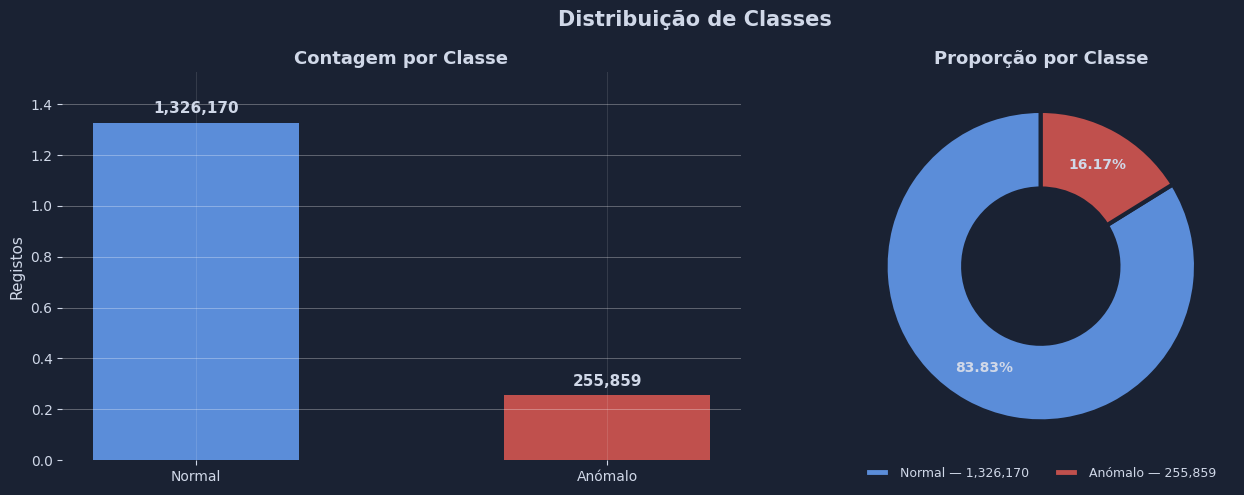

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Classes')

contagens = df['label'].value_counts().sort_index()
labels_str = ['Normal', 'Anómalo']
cores = [BLUE, RED]

# Barplot
bars = axes[0].bar(labels_str, contagens.values, color=cores, width=0.5)
axes[0].yaxis.offsetText.set_visible(False)
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Registos')
axes[0].set_xlabel('')
for bar, v in zip(bars, contagens.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + contagens.max()*0.02,
                 f'{v:,}', ha='center', va='bottom',
                 color=TEXT_COLOR, fontweight='bold', fontsize=11)
axes[0].set_ylim(0, contagens.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    contagens.values,
    colors=cores,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 3, 'width': 0.5}
)
for t in autotexts:
    t.set_color(TEXT_COLOR)
    t.set_fontsize(10)
    t.set_fontweight('bold')
for t in texts:
    t.set_color(TEXT_COLOR)

axes[1].set_title('Proporção por Classe')
axes[1].legend(
    [f'Normal — {contagens[0]:,}', f'Anómalo — {contagens[1]:,}'],
    loc='lower center', bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=9, frameon=False
)

plt.tight_layout()
plt.show()

## 8. Distribuição das Features Numéricas (percentil 99)
Distribuição das primeiras 9 features de pseudo-labelling por classe (Normal vs Anómalo).
Os valores são truncados ao percentil 99 para remover o efeito de outliers extremos
e permitir uma visualização clara da distribuição central de cada feature.

## Este conjunto de 9 histogramas mostra a distribuição de cada feature de pseudo-labelling, comparando tráfego Normal (azul) vs Anómalo (vermelho), truncados ao percentil 99 para remover o efeito de outliers extremos.

| Feature | Descrição | Padrão de Anomalia |
|---|---|---|
| **Flow Duration** | Duração total do fluxo de rede em microssegundos. | Distribuição muito mais dispersa e com picos em durações muito elevadas — típico de ataques DoS lentos (slowloris) que mantêm conexões abertas deliberadamente. |
| **Total Fwd Packets** | Número total de pacotes enviados no sentido cliente->servidor. | Mais pacotes enviados — consistente com ataques de flooding. |
| **Total Backward Packets** | Número total de pacotes no sentido servidor->cliente. | Padrão distinto do normal — em ataques DoS o servidor responde pouco ou de forma anómala. |
| **Total Length of Fwd Packets** | Volume total de bytes enviados (cliente->servidor). | Picos em valores elevados — indicativo de ataques volumétricos. |
| **Total Length of Bwd Packets** | Volume total de bytes recebidos (servidor->cliente). | Distribuição muito concentrada num valor específico — padrão de resposta repetitiva do servidor. |
| **Flow Bytes/s** | Taxa de transferência de bytes por segundo. | Valores negativos no eixo X indicam outliers extremos que distorcem a escala — estes registos devem ser investigados, pois bytes/s negativo não é fisicamente possível e sugere overflow aritmético no CICFlowMeter. |
| **Flow Packets/s** | Taxa de pacotes por segundo. | Pico muito concentrado — padrão de flooding a taxa constante, característico de DDoS. |
| **Fwd Packets/s** | Taxa de pacotes enviados por segundo (cliente->servidor). | Semelhante ao Flow Packets/s mas apenas na direção de envio. |
| **Bwd Packets/s** | Taxa de pacotes recebidos por segundo (servidor->cliente). | Distribuição muito diferente do normal — o servidor responde a um ritmo anómalo. |

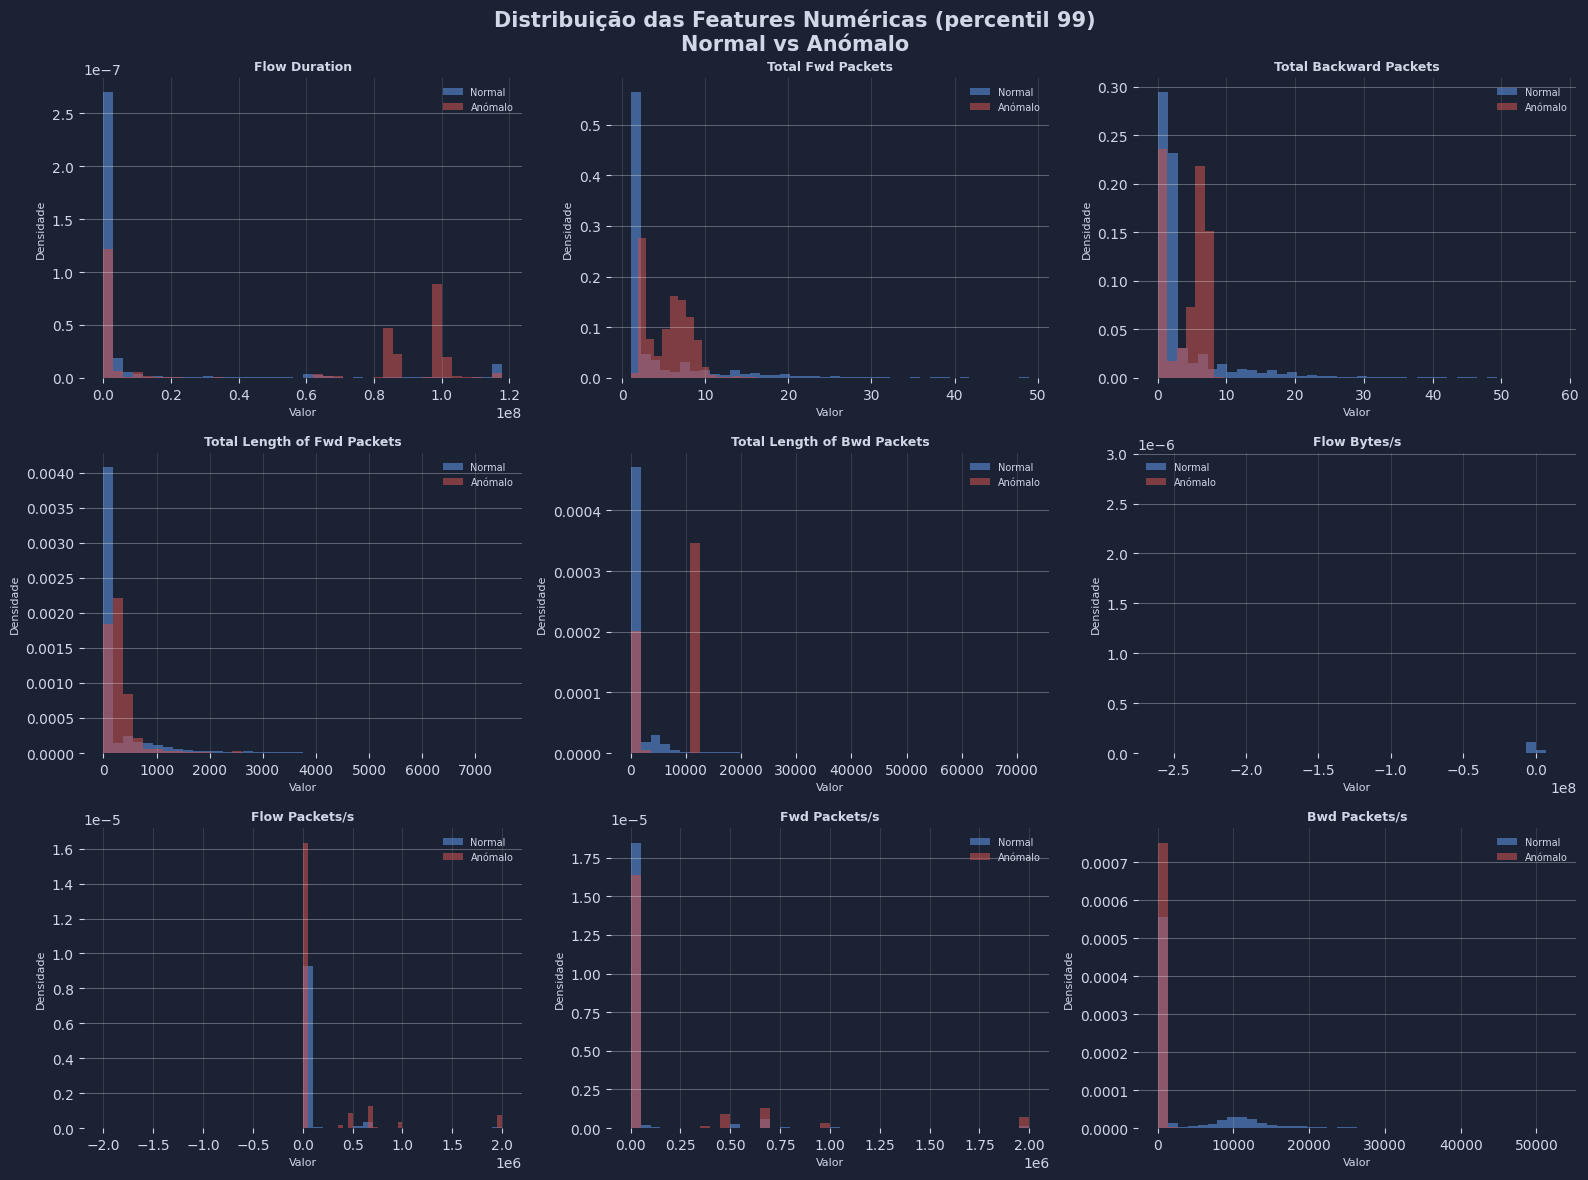

In [45]:
# primeiras 9 para visualização
features_plot = features_pl[:9]  
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribuição das Features Numéricas (percentil 99)\nNormal vs Anómalo')
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    for classe, cor, nome in [(0, BLUE, 'Normal'), (1, RED, 'Anómalo')]:
        subset = dados[dados['label'] == classe][feat]
        axes[i].hist(subset, bins=40, color=cor, alpha=0.6,
                     label=nome, density=True, edgecolor='none')

    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Densidade', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Matriz de Correlação — Features do Modelo Supervisionado
Visualização interactiva das correlações entre as 50 features do modelo supervisionado.
O coeficiente de correlação de Pearson varia entre -1 e 1:
Azul escuro = correlação positiva forte (+1) | Branco = sem correlação (0) | Vermelho escuro = correlação negativa forte (-1)

A matriz é apresentada em formato interactivo — é possível fazer hover em cada célula
para ver o valor exacto da correlação entre qualquer par de features.

In [46]:
corr = df[features_modelo].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.columns.tolist(),
    colorscale='RdBu',
    zmin=-1, 
    zmax=1,
    zmid=0,
    hoverongaps=False,
    hovertemplate='<b>%{y}</b> × <b>%{x}</b><br>Correlação: %{z:.3f}<extra></extra>',
    colorbar=dict(
        title=dict(
            text='Correlação',
            font=dict(color=TEXT_COLOR, size=13)
        ),
        tickfont=dict(color=TEXT_COLOR, size=11),
        bgcolor=BG_COLOR,
        bordercolor=GRID_COLOR,
    )
))

fig.update_layout(
    title=dict(
        text='Matriz de Correlação — Features do Modelo Supervisionado<br><sup>Azul escuro = correlação positiva forte | Branco = sem correlação | Vermelho escuro = correlação negativa forte</sup>',
        font=dict(color=TEXT_COLOR, size=18),
        x=0.5,
        xanchor='center'
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=BG_COLOR,
    font=dict(color=TEXT_COLOR, size=7),
    width=1300,
    height=1200,
    xaxis=dict(
        tickangle=45,
        tickfont=dict(size=11, color=TEXT_COLOR),
        gridcolor=GRID_COLOR,
        autorange='reversed'
    ),
    yaxis=dict(
        tickfont=dict(size=11, color=TEXT_COLOR),
        gridcolor=GRID_COLOR,
        autorange='reversed'
    )
)

fig.show()


## 10. Boxplots por Classe
Distribuição das features de pseudo-labelling por classe (Normal vs Anómalo).
Permite identificar diferenças na distribuição e outliers entre as duas classes.

| Feature | Descrição | Padrão de Anomalia |
|---|---|---|
| **Flow Duration** | Duração total do fluxo. | Mediana muito superior ao normal e grande dispersão — típico de ataques DoS lentos que mantêm conexões abertas deliberadamente. |
| **Total Fwd Packets** | Pacotes enviados (cliente->servidor). | Mais pacotes e maior variância — consistente com flooding repetitivo. |
| **Total Backward Packets** | Pacotes recebidos (servidor->cliente). | Distribuição mais dispersa — o servidor responde de forma irregular a tráfego malicioso. |
| **Total Length of Fwd Packets** | Volume de bytes enviados. | Valores mais elevados — payloads maiores em Web Attacks e DoS volumétrico. |
| **Total Length of Bwd Packets** | Volume de bytes recebidos. | Concentrados num valor específico — resposta repetitiva do servidor a ataques. |
| **Flow Bytes/s** | Taxa de transferência de bytes por segundo. | Valores negativos indicam overflow aritmético do CICFlowMeter — registos a investigar. |
| **Flow Packets/s** | Taxa de pacotes por segundo. | Pico muito concentrado — padrão de flooding a taxa constante. |
| **Fwd Packets/s** | Taxa de pacotes enviados. | Distribuição muito distinta — ritmo de envio anormal. |
| **Bwd Packets/s** | Taxa de pacotes recebidos. | Maior variância — o servidor responde a ritmo irregular. |
| **Flow IAT Mean** | Intervalo médio entre pacotes do fluxo. | Valores muito superiores — ataques lentos (slowloris) espaçam pacotes deliberadamente. |
| **Flow IAT Std** | Desvio padrão do intervalo entre pacotes. | Maior dispersão — timing irregular característico de ataques adaptativos. |
| **Flow IAT Max** | Intervalo máximo entre pacotes. | Valores extremamente elevados — pausas longas deliberadas para evadir detecção. |
| **Flow IAT Min** | Intervalo mínimo entre pacotes. | Distribuições semelhantes — feature menos discriminativa isoladamente. |
| **Packet Length Mean** | Tamanho médio dos pacotes. | Valores claramente superiores — payloads maiores em Web Attacks e Botnet. |
| **Packet Length Std** | Desvio padrão do tamanho dos pacotes. | Maior dispersão — variação irregular no tamanho dos pacotes maliciosos. |
| **Min Packet Length** | Tamanho mínimo de pacote. | Distribuição mais ampla no normal — o tráfego normal tem maior variedade de tamanhos mínimos. |
| **Max Packet Length** | Tamanho máximo de pacote. | Valores superiores — pacotes maiores associados a payloads de ataque. |

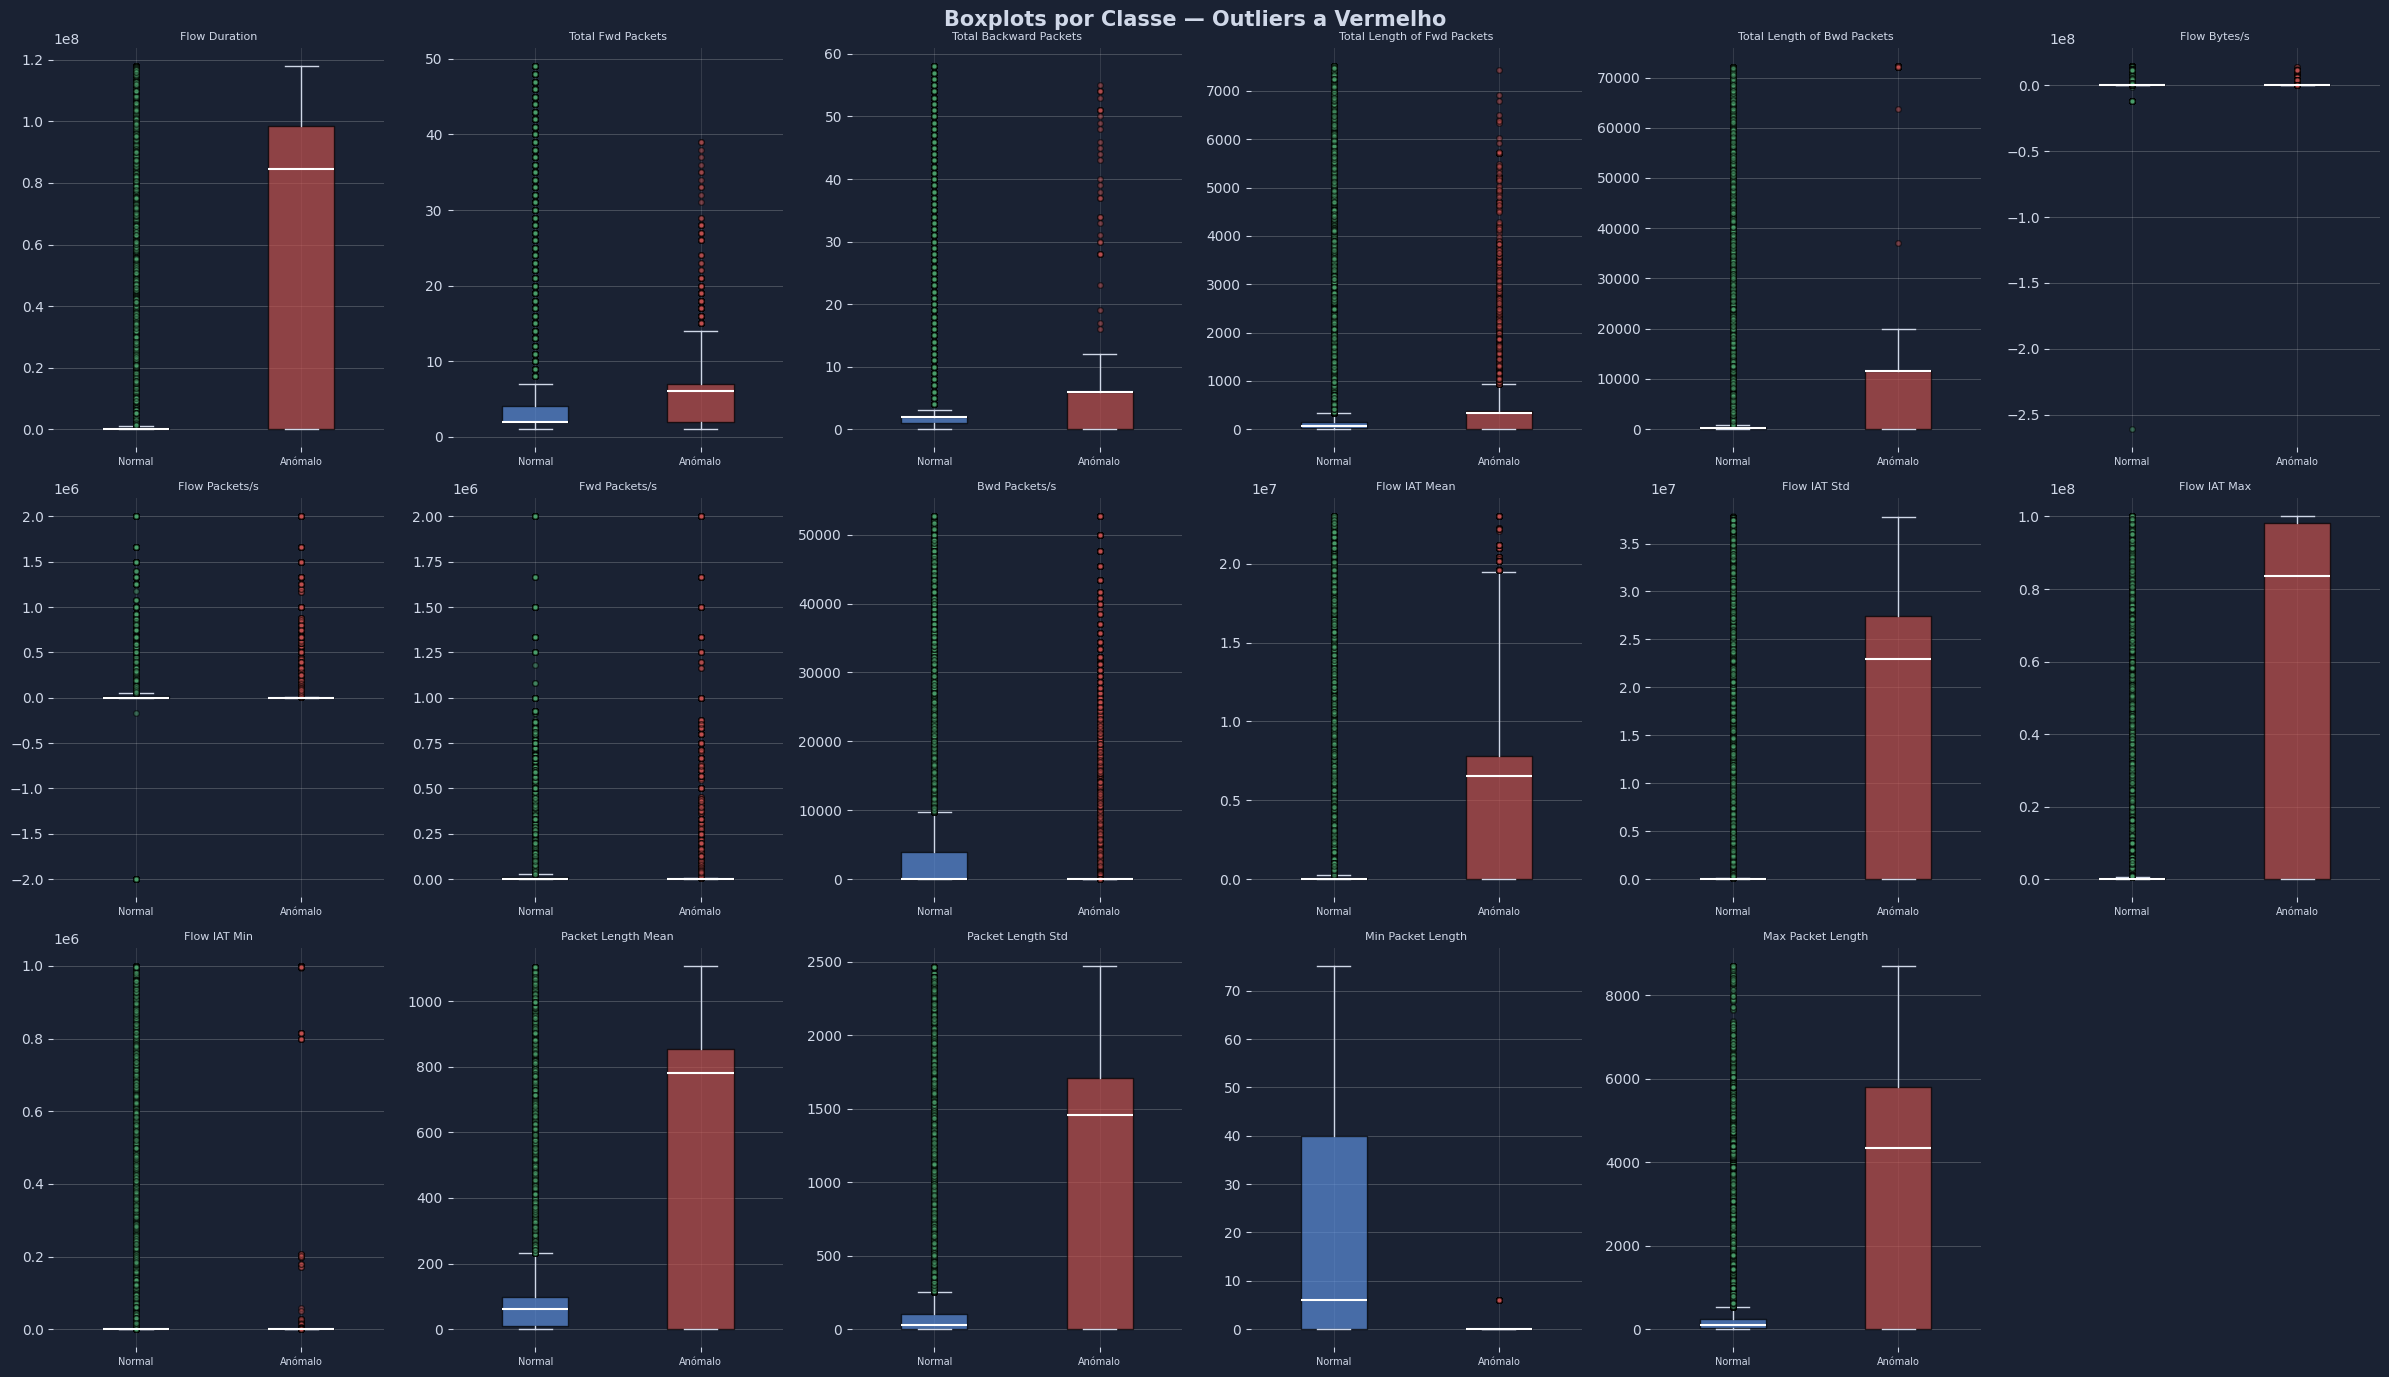

In [47]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Boxplots por Classe — Outliers a Vermelho')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    normal = dados[dados['label'] == 0][feat]
    anomalo = dados[dados['label'] == 1][feat]

    bp0 = axes[i].boxplot(normal, positions=[0], widths=0.4,
                          patch_artist=True,
                          flierprops=dict(marker='o', color='#4a9e6b', markerfacecolor='#4a9e6b', markersize=4, alpha=0.5, linestyle='none'),
                          medianprops=dict(color='white', linewidth=1.5),
                          boxprops=dict(facecolor=BLUE, alpha=0.7),
                          whiskerprops=dict(color=TEXT_COLOR),
                          capprops=dict(color=TEXT_COLOR))

    bp1 = axes[i].boxplot(anomalo, positions=[1], widths=0.4,
                          patch_artist=True,
                          flierprops=dict(marker='o', color='#c05050', markerfacecolor='#c05050', markersize=4, alpha=0.5, linestyle='none'),
                          medianprops=dict(color='white', linewidth=1.5),
                          boxprops=dict(facecolor=RED, alpha=0.7),
                          whiskerprops=dict(color=TEXT_COLOR),
                          capprops=dict(color=TEXT_COLOR))

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Anómalo'], fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

# Remover subplots vazios
for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 11. Violin Plot por Classe
Distribuição das 17 features de pseudo-labelling por classe (Normal vs Anómalo)
com densidade de probabilidade. A linha branca representa a mediana de cada distribuição.
A largura do violino em cada ponto representa a densidade de registos nesse valor —
quanto mais largo, mais registos têm esse valor.

| Feature | Descrição | Padrão de Anomalia |
|---|---|---|
| **Flow Duration** | Duração total do fluxo. | Distribuição muito larga e assimétrica, estendendo-se até valores muito elevados — confirma a presença de ataques de longa duração como Slowloris. Normais concentrados junto ao zero com violino muito estreito. |
| **Total Fwd Packets** | Número total de pacotes enviados (cliente->servidor). | Normais com violino estreito e concentrado em valores baixos. Anómalos com distribuição mais larga e cauda superior pronunciada — fluxos de ataque enviam mais pacotes com maior variabilidade. |
| **Total Backward Packets** | Número total de pacotes recebidos (servidor->cliente). | Padrão semelhante ao Fwd Packets mas com anómalos mais dispersos — o servidor responde de forma irregular a tráfego malicioso. |
| **Total Length of Fwd Packets** | Volume total de bytes enviados (cliente->servidor). | Violino mais largo e deslocado para valores superiores — payloads maiores em Web Attacks e DoS volumétrico. |
| **Total Length of Bwd Packets** | Volume total de bytes recebidos (servidor->cliente). | Violino muito estreito e concentrado num valor específico — resposta repetitiva e uniforme do servidor, característica de DoS. |
| **Flow Bytes/s** | Taxa de transferência de bytes por segundo. | Ambas as classes com violinos estreitos — a presença de valores negativos (overflow do CICFlowMeter) distorce a escala e limita a interpretação. |
| **Flow Packets/s** | Taxa de pacotes por segundo. | Normais com violino estreito junto ao zero. Anómalos com distribuição muito mais larga — taxas de pacotes muito variáveis nos ataques. |
| **Fwd Packets/s** | Taxa de pacotes enviados por segundo (cliente->servidor). | Semelhante ao Flow Packets/s — anómalos com maior dispersão e cauda superior pronunciada. |
| **Bwd Packets/s** | Taxa de pacotes recebidos por segundo (servidor->cliente). | Violino claramente diferente do normal — o servidor responde a taxas anormais em resposta a tráfego malicioso. |
| **Flow IAT Mean** | Intervalo médio entre pacotes do fluxo. | Uma das diferenças mais pronunciadas — anómalos com violino muito mais largo e deslocado para valores superiores. Ataques lentos espaçam deliberadamente os pacotes, aumentando o intervalo médio. |
| **Flow IAT Std** | Desvio padrão do intervalo entre pacotes. | Violino muito mais largo nos anómalos — grande variabilidade no timing entre pacotes, característica de ataques adaptativos que variam o ritmo para evadir detecção. |
| **Flow IAT Max** | Intervalo máximo entre pacotes. | Cauda superior muito pronunciada nos anómalos — pausas muito longas entre pacotes, típico de ataques que mantêm conexões abertas com atividade mínima. |
| **Flow IAT Min** | Intervalo mínimo entre pacotes. | Distribuições mais semelhantes entre classes — feature menos discriminativa isoladamente, mas útil em combinação com outras features de IAT. |
| **Packet Length Mean** | Tamanho médio dos pacotes. | Anómalos claramente deslocados para valores superiores — payloads maiores associados a Web Attacks (SQLi, XSS) e Botnet. |
| **Packet Length Std** | Desvio padrão do tamanho dos pacotes. | Anómalos com maior dispersão — variação irregular no tamanho dos pacotes maliciosos, refletindo a diversidade de tipos de ataque. |
| **Min Packet Length** | Tamanho mínimo de pacote. | Normal com violino mais largo — o tráfego normal tem maior variedade de tamanhos mínimos de pacote. Anómalos mais concentrados. |
| **Max Packet Length** | Tamanho máximo de pacote. | Violino deslocado para valores superiores nos anómalos — pacotes maiores associados a payloads de ataque mais volumosos. |

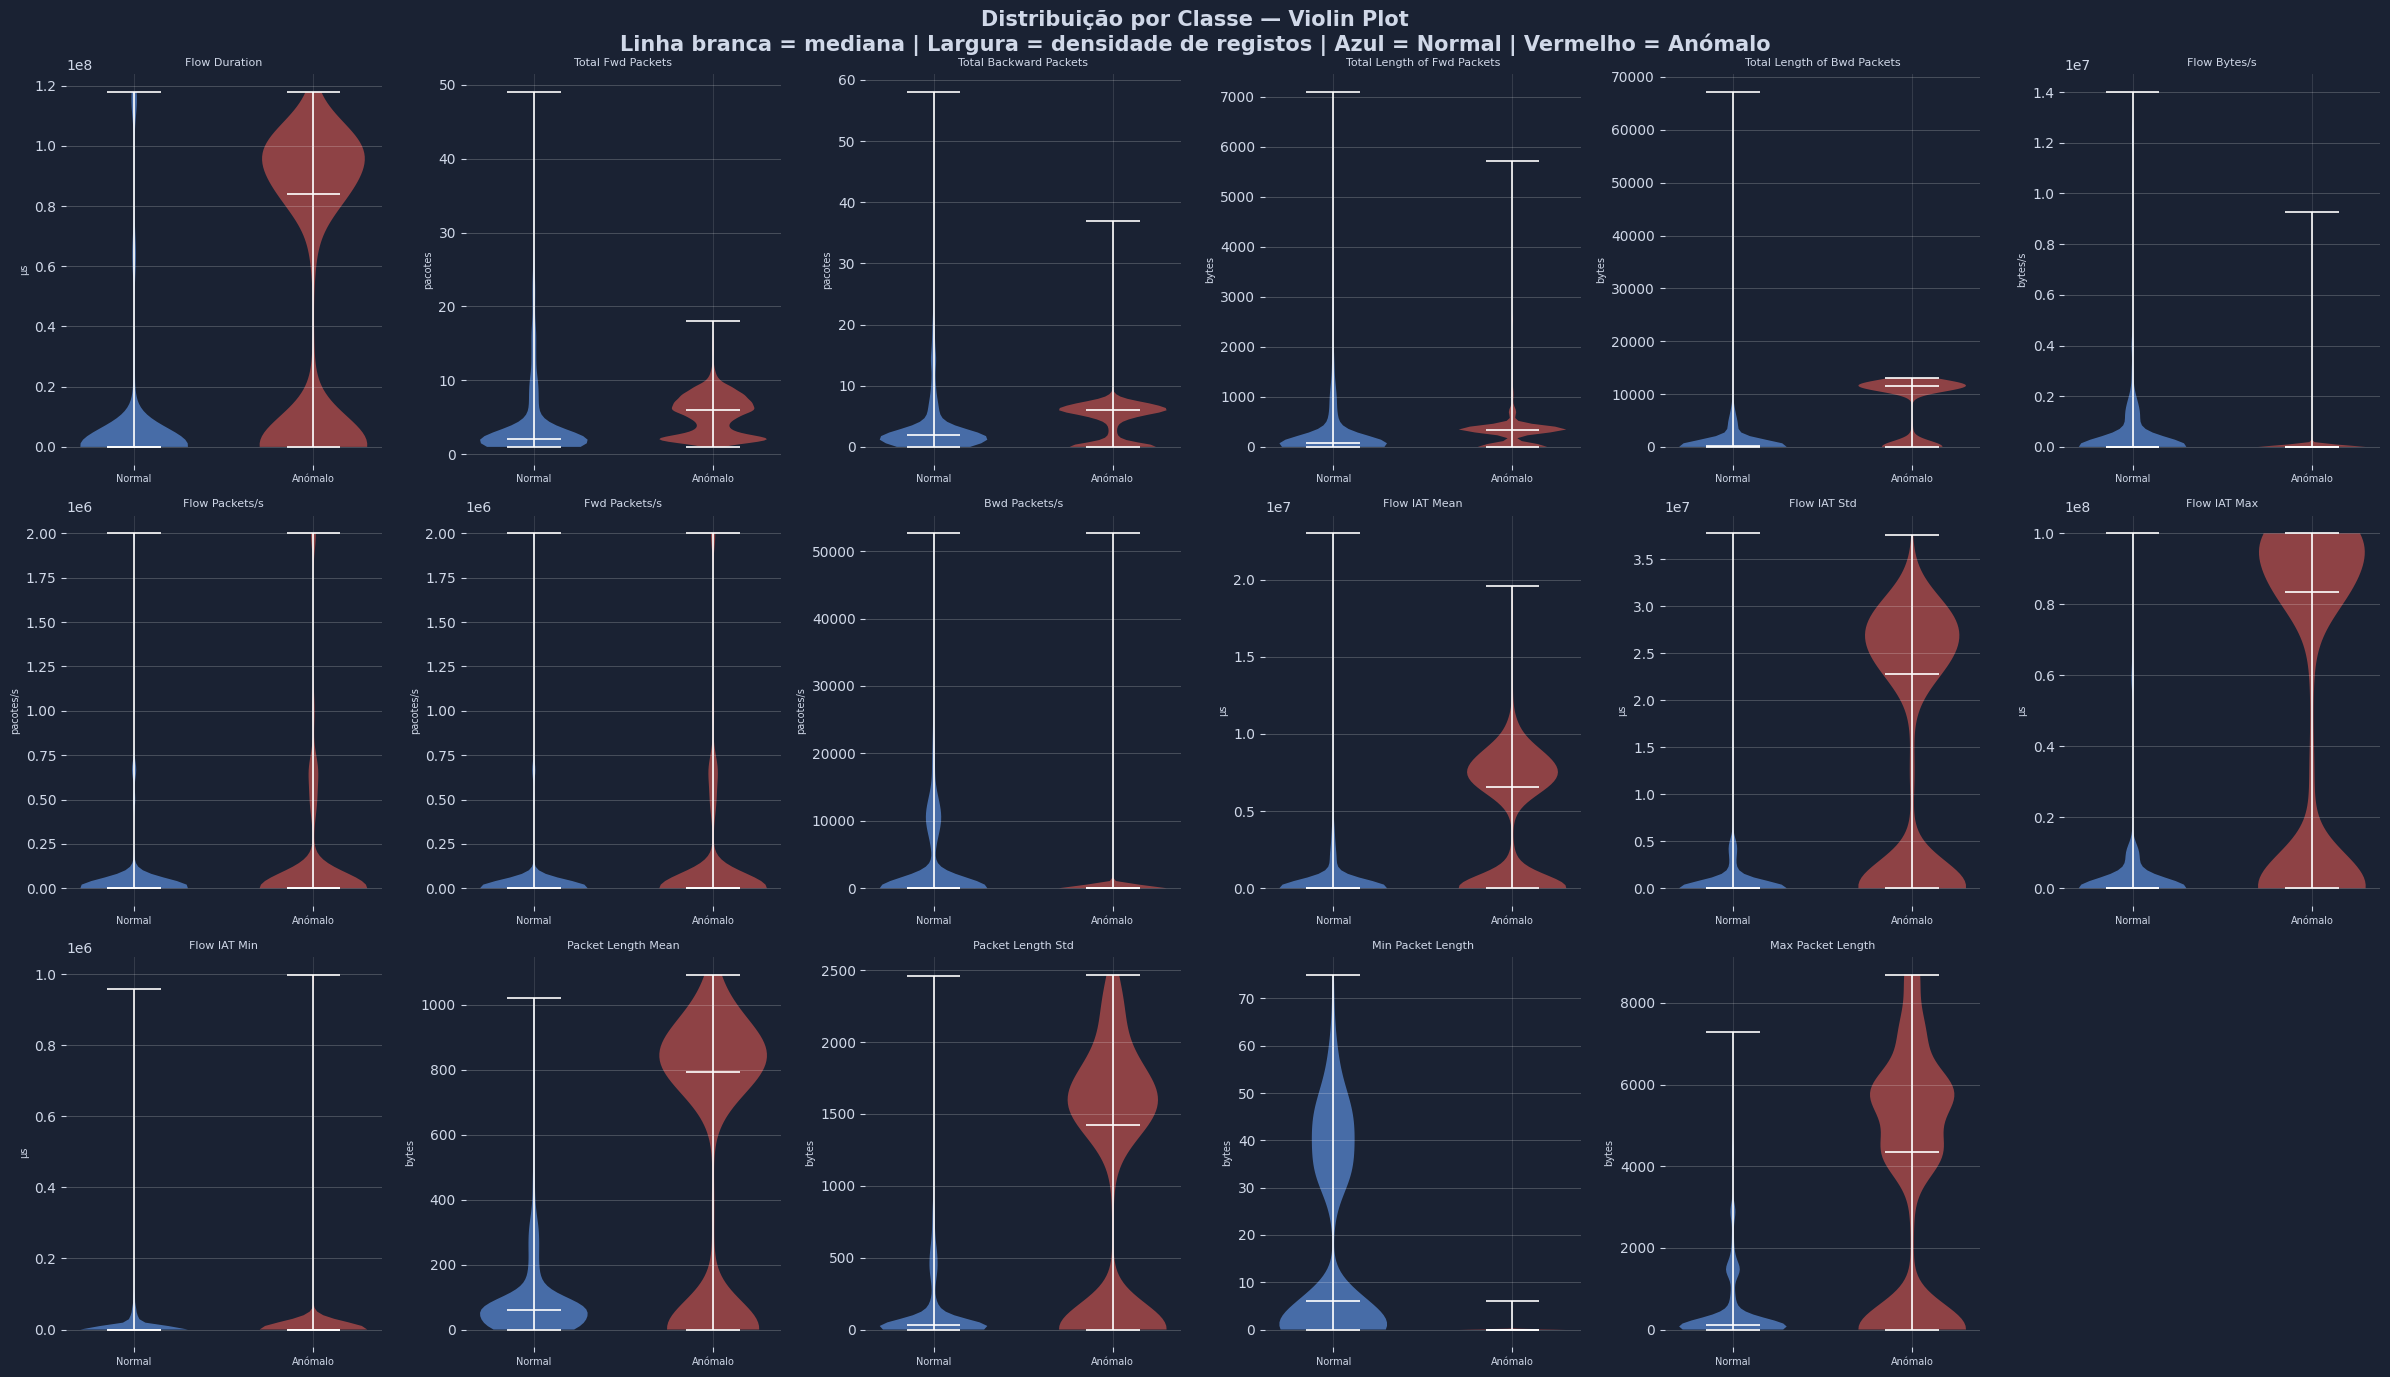

In [48]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Distribuição por Classe — Violin Plot\n'
             'Linha branca = mediana | Largura = densidade de registos | '
             'Azul = Normal | Vermelho = Anómalo')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    normal = dados[dados['label'] == 0][feat].sample(min(3000, len(dados[dados['label'] == 0])), random_state=42)
    anomalo = dados[dados['label'] == 1][feat].sample(min(3000, len(dados[dados['label'] == 1])), random_state=42)

    parts0 = axes[i].violinplot(normal, positions=[0], widths=0.6, showmedians=True)
    parts1 = axes[i].violinplot(anomalo, positions=[1], widths=0.6, showmedians=True)

    for pc in parts0['bodies']:
        pc.set_facecolor(BLUE)
        pc.set_alpha(0.7)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts0[part].set_color('white')
        parts0[part].set_linewidth(1.2)

    for pc in parts1['bodies']:
        pc.set_facecolor(RED)
        pc.set_alpha(0.7)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts1[part].set_color('white')
        parts1[part].set_linewidth(1.2)

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_xticks([0, 1])
    axes[i].set_ylabel(unidades_features.get(feat, 'Valor'), fontsize=7)
    axes[i].set_xticklabels(['Normal', 'Anómalo'], fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 12. Total Fwd Packets vs Total Backward Packets — Distribuições Marginais
Relação entre o número de pacotes enviados (cliente->servidor) e recebidos
(servidor->cliente) por fluxo, com distribuições marginais de densidade (KDE).

**Interpretação:**
O tráfego normal concentra-se no canto inferior esquerdo — poucas sessões HTTP
convencionais têm muitos pacotes em ambas as direcções. Os ataques concentram-se
em valores baixos de pacotes enviados mas com grande variação nos pacotes recebidos
— o atacante envia poucos pacotes mas provoca respostas desproporcionais do servidor,
padrão típico de ataques de amplificação e DoS.

A distribuição marginal direita (eixo Y) é a mais discriminativa — a cauda longa
dos anómalos nos pacotes recebidos confirma que o servidor responde de forma
mais volumosa ou repetitiva a tráfego malicioso.

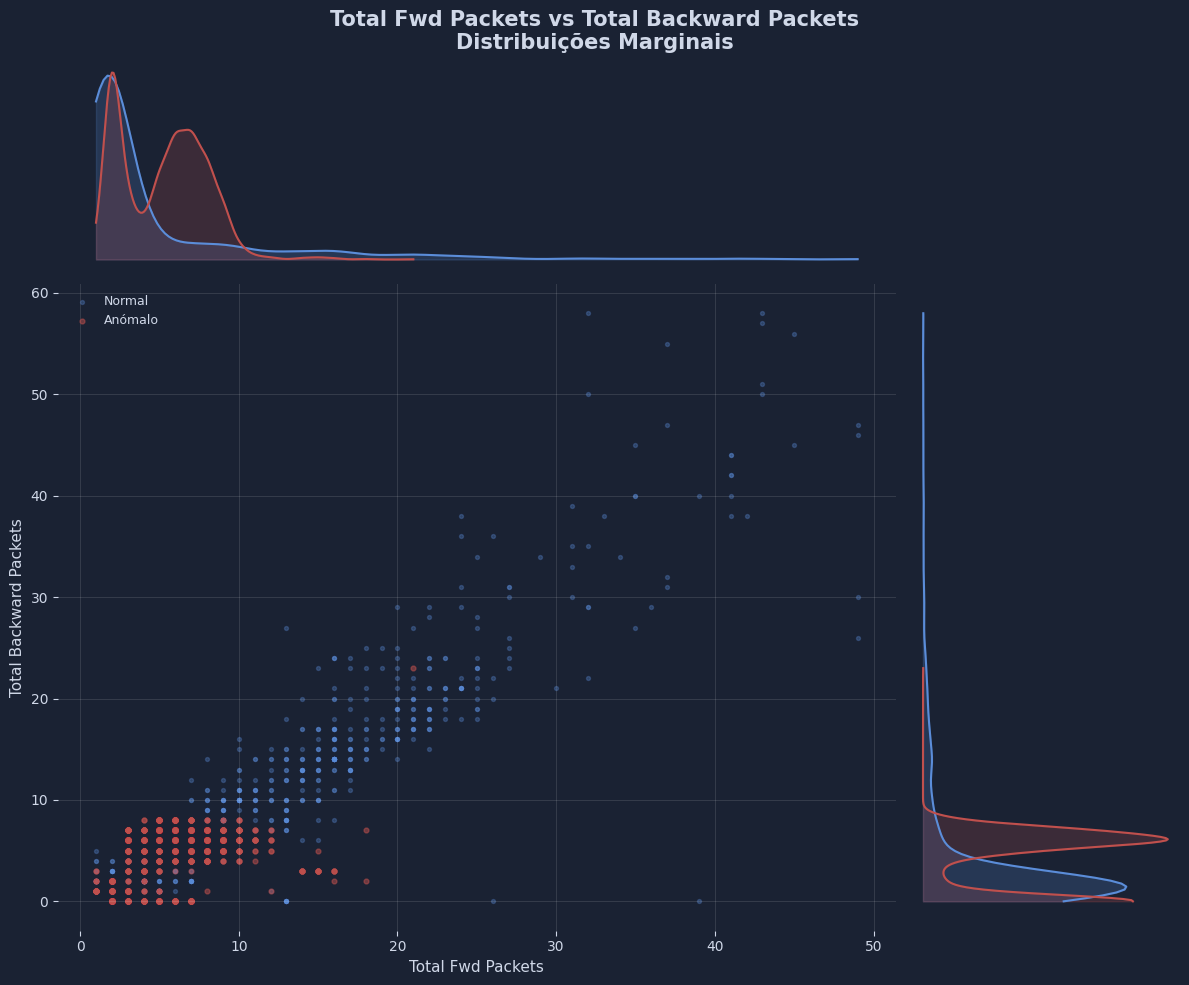

In [49]:
p99_x = df['Total Fwd Packets'].quantile(0.99)
p99_y = df['Total Backward Packets'].quantile(0.99)

dados = df[(df['Total Fwd Packets'] <= p99_x) & (df['Total Backward Packets'] <= p99_y)]
normal = dados[dados['label'] == 0].sample(min(3000, len(dados[dados['label'] == 0])), random_state=42)
anomalo = dados[dados['label'] == 1].sample(min(3000, len(dados[dados['label'] == 1])), random_state=42)

fig = plt.figure(figsize=(12, 10))
fig.suptitle('Total Fwd Packets vs Total Backward Packets\nDistribuições Marginais')

gs = GridSpec(4, 4, figure=fig)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_top   = fig.add_subplot(gs[0, 0:3])
ax_right = fig.add_subplot(gs[1:4, 3])

# Scatter principal
ax_main.scatter(normal['Total Fwd Packets'], normal['Total Backward Packets'],
                color=BLUE, alpha=0.3, s=8, label='Normal')
ax_main.scatter(anomalo['Total Fwd Packets'], anomalo['Total Backward Packets'],
                color=RED, alpha=0.5, s=12, label='Anómalo')
ax_main.set_xlabel('Total Fwd Packets')
ax_main.set_ylabel('Total Backward Packets')
ax_main.legend(fontsize=9, loc='upper left')

# KDE marginal superior
for dados_cls, cor in [(normal, BLUE), (anomalo, RED)]:
    kde = stats.gaussian_kde(dados_cls['Total Fwd Packets'])
    x_range = np.linspace(dados_cls['Total Fwd Packets'].min(),
                          dados_cls['Total Fwd Packets'].max(), 200)
    ax_top.plot(x_range, kde(x_range), color=cor, linewidth=1.5)
    ax_top.fill_between(x_range, kde(x_range), alpha=0.2, color=cor)
ax_top.set_xlim(ax_main.get_xlim())
ax_top.axis('off')

# KDE marginal direita
for dados_cls, cor in [(normal, BLUE), (anomalo, RED)]:
    kde = stats.gaussian_kde(dados_cls['Total Backward Packets'])
    y_range = np.linspace(dados_cls['Total Backward Packets'].min(),
                          dados_cls['Total Backward Packets'].max(), 200)
    ax_right.plot(kde(y_range), y_range, color=cor, linewidth=1.5)
    ax_right.fill_betweenx(y_range, kde(y_range), alpha=0.2, color=cor)
ax_right.set_ylim(ax_main.get_ylim())
ax_right.axis('off')

plt.tight_layout()
plt.show()

## 13. Matriz de Dispersão — Features Principais
Relação entre as 5 features de pseudo-labelling mais relevantes por classe
(Normal vs Anómalo). A diagonal mostra a distribuição de densidade (KDE)
de cada feature individualmente.

**Interpretação:**
A separação visual entre classes é notória em várias combinações de features:

| Par de Features / Eixo | Padrão de Anomalia |
|---|---|
| **Total Fwd Packets vs Total Backward Packets** | Anómalos concentrados em valores baixos de pacotes enviados mas com maior dispersão nos recebidos — padrão de amplificação já identificado no gráfico anterior. |
| **Flow Bytes/s vs Total Fwd/Bwd Packets** | Separação clara entre classes — ataques tendem a ter taxas de bytes por segundo muito distintas do tráfego normal. |
| **Packet Length Mean vs restantes features** | Anómalos deslocados para valores superiores de tamanho médio de pacote — payloads maiores associados a Web Attacks e Botnet. |
| **Diagonal (KDE individual)** | Confirma as diferenças de distribuição já observadas nos histogramas e violin plots — anómalos têm distribuições mais dispersas e deslocadas em Flow Bytes/s e Packet Length Mean. |

**Conclusão:** nenhuma feature isolada separa perfeitamente as duas classes —
é a combinação de múltiplas features que permite ao modelo supervisionado
atingir ROC-AUC de 0,8951.

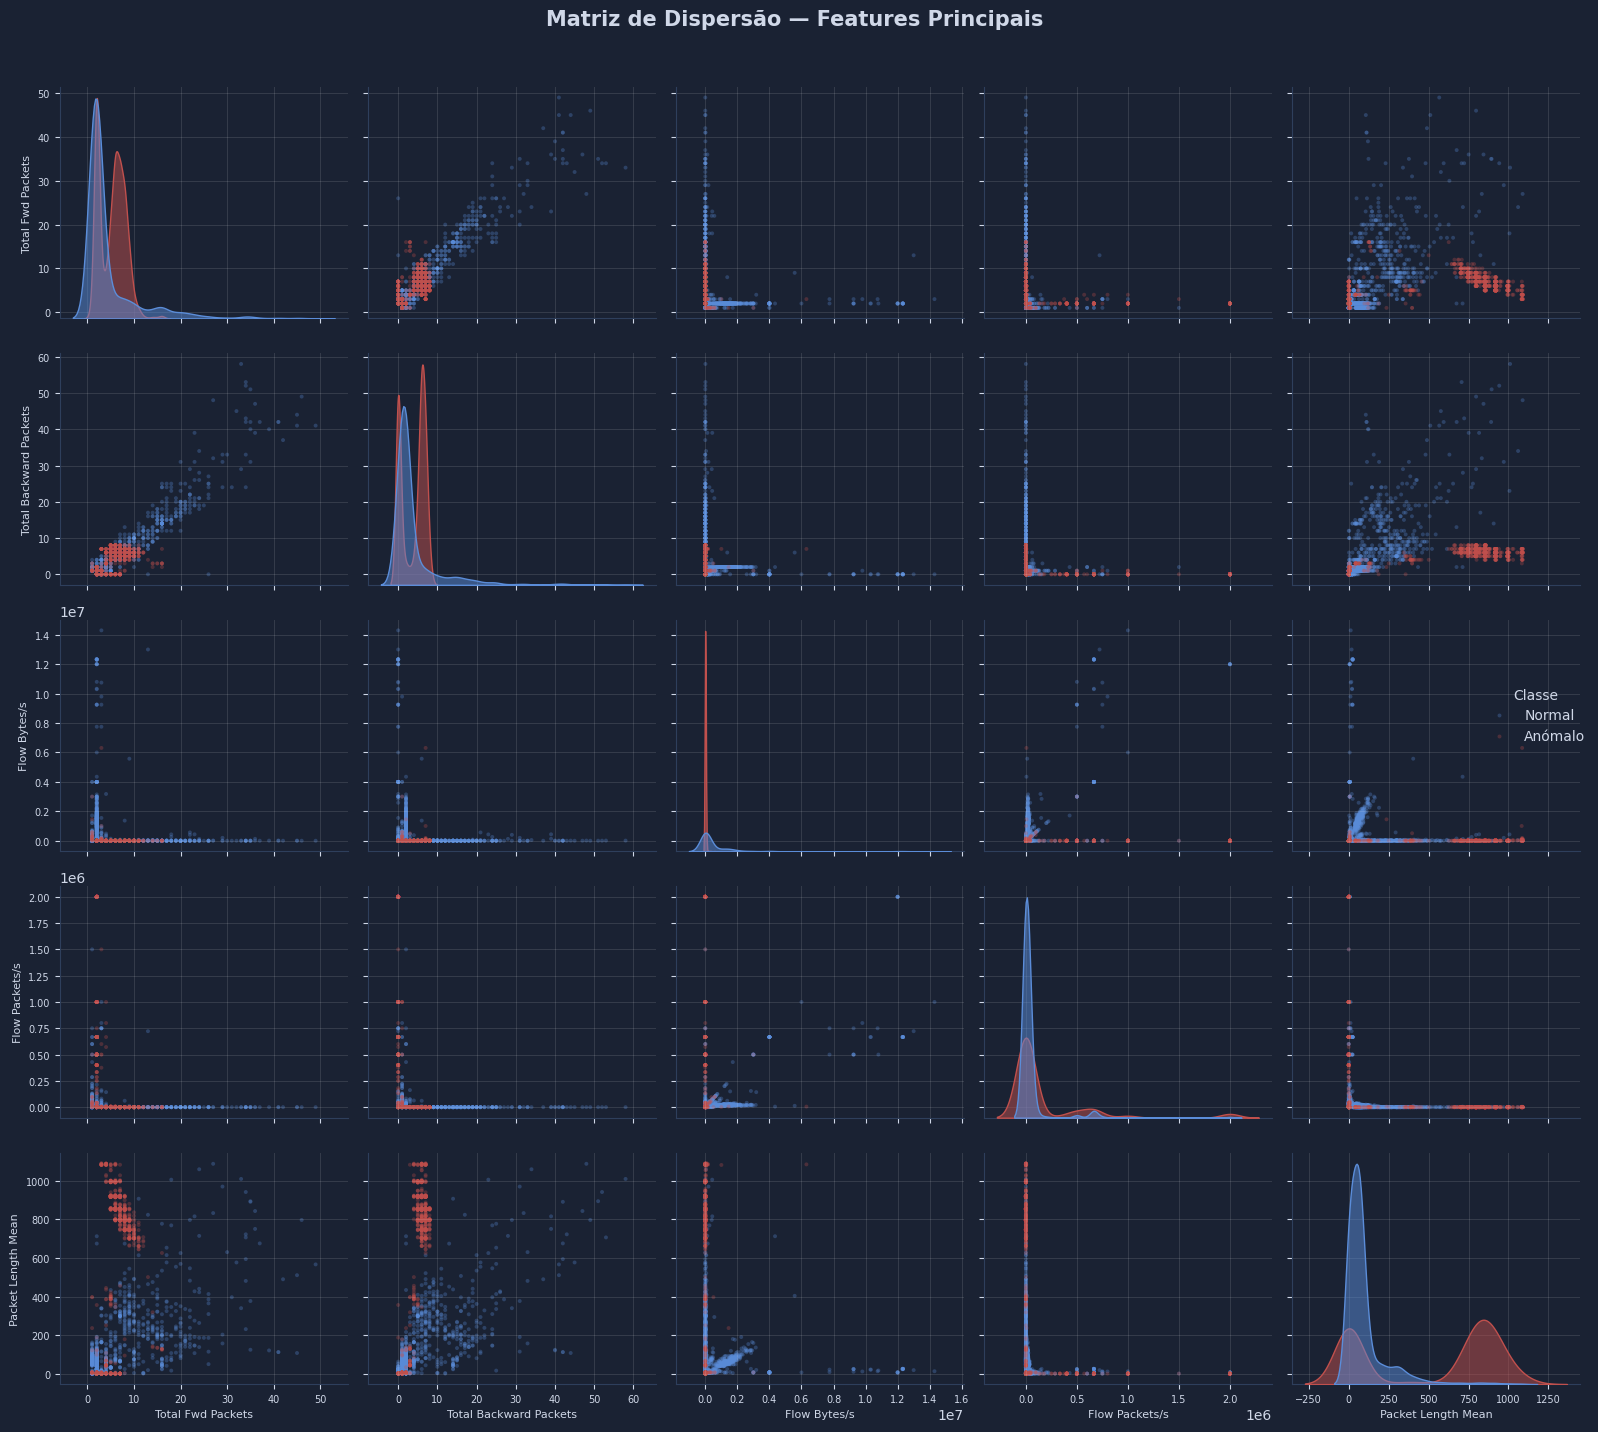

In [15]:
features_pairplot = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'
]

p99 = df[features_pairplot].quantile(0.99)
dados_pp = df[(df[features_pairplot] <= p99).all(axis=1)].copy()
dados_pp['Classe'] = dados_pp['label'].map({0: 'Normal', 1: 'Anómalo'})

sample_normal  = dados_pp[dados_pp['Classe'] == 'Normal'].sample(2000, random_state=42)
sample_anomalo = dados_pp[dados_pp['Classe'] == 'Anómalo'].sample(min(2000, len(dados_pp[dados_pp['Classe'] == 'Anómalo'])), random_state=42)
dados_sample = pd.concat([sample_normal, sample_anomalo])

g = sns.pairplot(
    dados_sample,
    vars=features_pairplot,
    hue='Classe',
    palette={'Normal': BLUE, 'Anómalo': RED},
    plot_kws=dict(alpha=0.3, s=8, edgecolor='none'),
    diag_kws=dict(fill=True, alpha=0.5),
    diag_kind='kde',
    corner=False
)

g.figure.suptitle('Matriz de Dispersão — Features Principais', y=1.02)
g.figure.set_size_inches(16, 14)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(BG_COLOR)
        ax.figure.set_facecolor(BG_COLOR)
        ax.tick_params(colors=TEXT_COLOR, labelsize=7)
        ax.xaxis.label.set_color(TEXT_COLOR)
        ax.yaxis.label.set_color(TEXT_COLOR)
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)

g._legend.set_title('Classe')
plt.setp(g._legend.get_texts(), color=TEXT_COLOR)
plt.setp(g._legend.get_title(), color=TEXT_COLOR)
g._legend.get_frame().set_facecolor(BG_COLOR)
g._legend.get_frame().set_edgecolor(GRID_COLOR)

plt.tight_layout()
plt.show()

## 14. Distribuição Acumulada (CDF) por Classe
Comparação da distribuição acumulada das 17 features de pseudo-labelling
entre tráfego Normal (azul) e Anómalo (vermelho).

A CDF (Cumulative Distribution Function) responde à pergunta: "que percentagem
dos fluxos tem um valor inferior ou igual a X?" — quanto mais afastadas as duas
curvas, maior o poder discriminativo da feature para o modelo.

**Como interpretar:**
- Curvas muito afastadas -> feature discriminativa — o modelo consegue usar esta
  feature para distinguir ataques de tráfego normal
- Curvas próximas ou sobrepostas -> feature pouco discriminativa isoladamente
- Curva que sobe rapidamente -> valores concentrados em valores baixos
- Curva que sobe lentamente -> valores dispersos ao longo de um intervalo largo

**Interpretação por feature:**

| Feature | Separação | Interpretação |
|---|---|---|
| **Flow Duration** | Muito afastada | Anómalos acumulam probabilidade muito mais lentamente, confirmando durações muito superiores ao normal. |
| **Total Fwd/Bwd Packets** | Moderada | Anómalos têm mais pacotes em ambas as direções, mas com sobreposição parcial com o normal. |
| **Total Length Fwd/Bwd Packets** | Clara | Anómalos com volumes de bytes superiores, especialmente na direção servidor->cliente. |
| **Flow Bytes/s e Flow Packets/s** | Próxima, apenas nas caudas | A diferença está nos casos extremos, não nos valores típicos. |
| **Flow IAT Mean/Std** | Muito afastada (das mais discriminativas) | Anómalos acumulam muito mais lentamente — intervalos entre pacotes muito superiores ao normal, um dos melhores indicadores de ataque. |
| **Flow IAT Max** | Muito afastada (das mais discriminativas) | Normal sobe rapidamente (pausas máximas curtas); anómalo sobe muito lentamente com cauda longa (pausas máximas muito superiores). Característico de Slowloris, Botnet (C2 com silêncios longos) e DoS lento. Confirma importância de 0.0614 no Random Forest. |
| **Flow IAT Min** | Praticamente sobreposta | Feature menos discriminativa isoladamente — valores mínimos de intervalo semelhantes entre normal e anómalo. |
| **Packet Length Mean/Std** | Clara | Anómalos com tamanhos de pacote superiores e mais variáveis. |
| **Min Packet Length** | Pronunciada | Normal acumula rapidamente em valores baixos; anómalos têm distribuição mais uniforme. |
| **Max Packet Length** | Clara | Anómalos com pacotes máximos maiores, associados a payloads de ataque volumosos. |

**Conclusão:** Flow IAT Mean, Flow IAT Max, Flow Duration e Packet Length
Mean são as features com maior poder discriminativo — as suas curvas CDF
apresentam a maior separação entre classes, confirmando os resultados
da feature importance do Random Forest (Subflow Bwd Bytes 0.1066,
Fwd IAT Total 0.1032, Average Packet Size 0.0866).

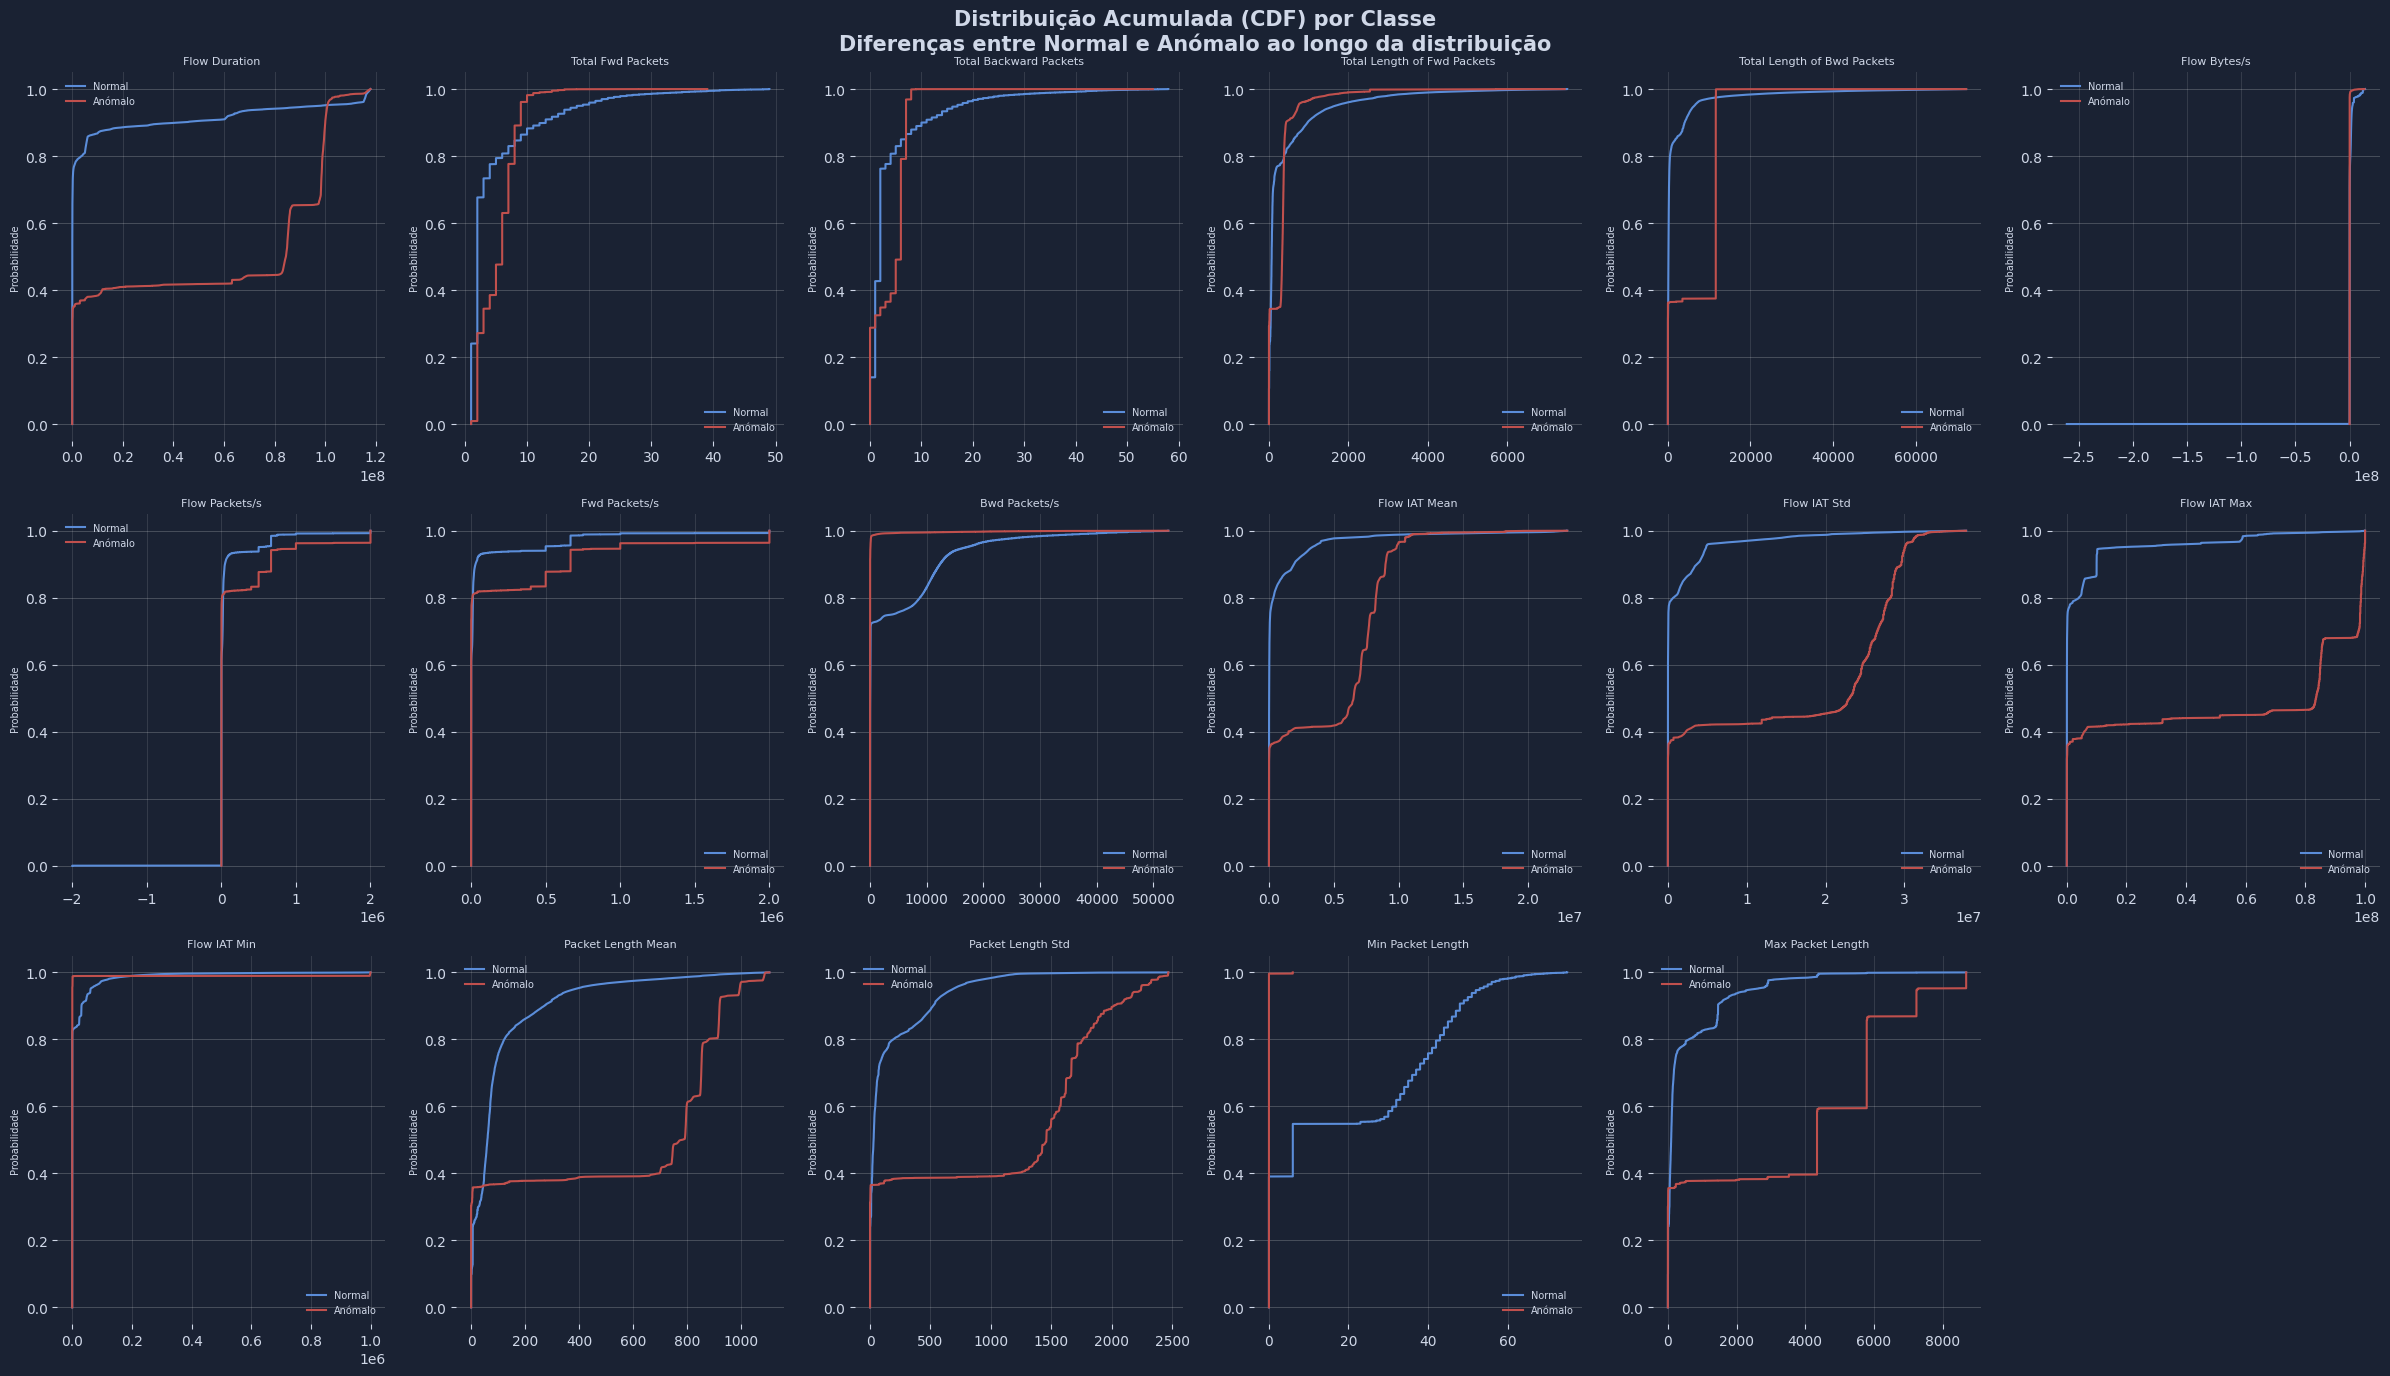

In [50]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Distribuição Acumulada (CDF) por Classe\nDiferenças entre Normal e Anómalo ao longo da distribuição')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    for classe, cor, nome in [(0, BLUE, 'Normal'), (1, RED, 'Anómalo')]:
        subset = dados[dados['label'] == classe][feat].dropna()
        subset_sorted = np.sort(subset)
        cdf = np.arange(1, len(subset_sorted) + 1) / len(subset_sorted)
        axes[i].plot(subset_sorted, cdf, color=cor, linewidth=1.5, label=nome)

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_ylabel('Probabilidade', fontsize=7)
    axes[i].legend(fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 15. Distribuição de Tráfego por Dia de Captura
Evolução do volume de tráfego normal e anómalo ao longo dos 4 dias de captura
do dataset CICIDS2017, e respectiva proporção de anomalias por dia.

**Como interpretar:**
O gráfico superior mostra o volume absoluto de fluxos normais (azul) e anómalos
(vermelho) por dia. O gráfico inferior mostra a percentagem de anomalias
relativamente ao total de tráfego de cada dia.

**Interpretação por dia:**

| Dia | Fluxos normais | Fluxos anómalos | % Anómalos | Descrição |
|---|---|---|---|---|
| **Monday** | 529.481 | 0 | 0,0% | Dia de baseline — apenas tráfego normal, sem ataques simulados. Referência para o comportamento esperado da rede. |
| **Wednesday** | 439.683 | 251.723 | 36,4% | Pico de actividade maliciosa — concentra ataques DoS/DDoS (Hulk, GoldenEye, Slowloris, Slowhttptest). Quase 1 em cada 3 fluxos é um ataque. |
| **Thursday** | 168.051 | 2.180 | 1,3% | Ataques Web (SQLi, XSS, Brute Force HTTP) — mais subtis e de menor volume do que os DoS de Wednesday. Proporção baixa reflecte a natureza dirigida destes ataques. |
| **Friday** | 188.955 | 1.956 | 1,0% | Tráfego de Botnet — comportamento persistente mas de baixa intensidade, difícil de detectar por volume. |

**Conclusões operacionais:**
- Wednesday é claramente o dia mais crítico — um sistema de monitorização
  em produção deveria gerar alertas massivos neste dia
- A queda abrupta de Thursday e Friday para ~1% não significa menos perigo —
  Web Attacks e Botnet são mais difíceis de detectar precisamente porque
  geram menos volume
- Monday serve como validação do modelo — qualquer anomalia detectada
  neste dia seria um falso positivo, dado que não há ataques reais

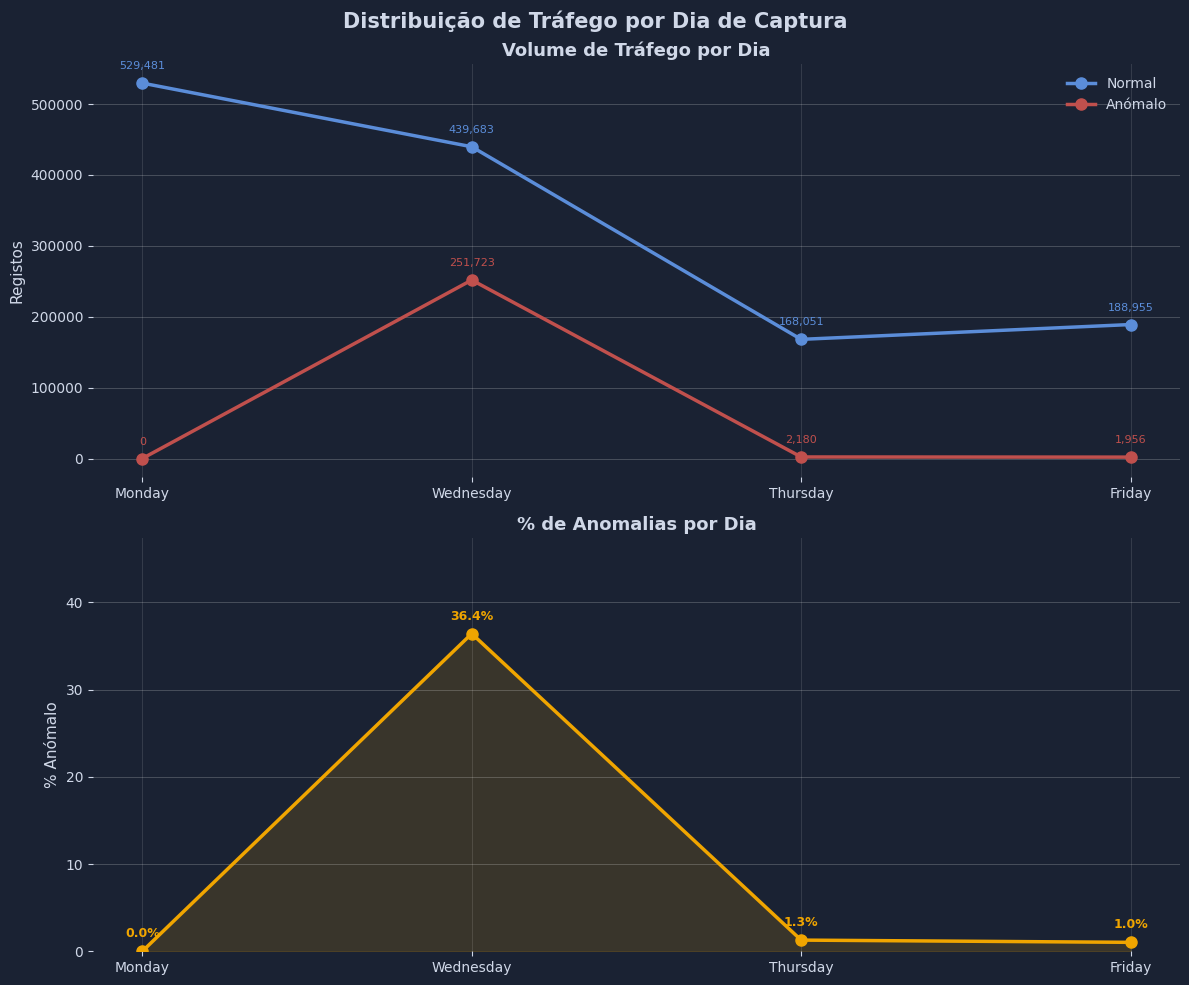

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Distribuição de Tráfego por Dia de Captura')

ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']

contagens = df.groupby(['day', 'label']).size().unstack(fill_value=0)
contagens = contagens.reindex(ordem_dias)
contagens.columns = ['Normal', 'Anómalo']

# Gráfico de linhas — contagem absoluta
axes[0].plot(ordem_dias, contagens['Normal'], color=BLUE, linewidth=2.5,
             marker='o', markersize=8, label='Normal')
axes[0].plot(ordem_dias, contagens['Anómalo'], color=RED, linewidth=2.5,
             marker='o', markersize=8, label='Anómalo')

for i, dia in enumerate(ordem_dias):
    axes[0].annotate(f"{contagens['Normal'][dia]:,}",
                     (dia, contagens['Normal'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=BLUE, fontsize=8)
    axes[0].annotate(f"{contagens['Anómalo'][dia]:,}",
                     (dia, contagens['Anómalo'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=RED, fontsize=8)

axes[0].set_title('Volume de Tráfego por Dia')
axes[0].set_ylabel('Registos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

# Gráfico de linhas — proporção de anomalias
proporcao = contagens['Anómalo'] / (contagens['Normal'] + contagens['Anómalo']) * 100

axes[1].plot(ordem_dias, proporcao.values, color=ORANGE, linewidth=2.5,
             marker='o', markersize=8)
axes[1].fill_between(ordem_dias, proporcao.values, alpha=0.15, color=ORANGE)

for i, (dia, val) in enumerate(zip(ordem_dias, proporcao.values)):
    axes[1].annotate(f'{val:.1f}%', (dia, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=ORANGE, fontsize=9, fontweight='bold')

axes[1].set_title('% de Anomalias por Dia')
axes[1].set_ylabel('% Anómalo')
axes[1].set_ylim(0, proporcao.max() * 1.3)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 16. Pseudo-Labelling — Consenso Ponderado IF + LOF

Geração de pseudo-labels através de um consenso ponderado entre Isolation Forest (IF)
e Local Outlier Factor (LOF), aplicado sobre uma amostra estratificada de 200.000 registos
que preserva a proporção original de classes (84% Normal / 16% Anómalo).

**Nota metodológica — Algoritmo:** A abordagem inicial previa o uso de DBSCAN em substituição do LOF.
No entanto, o DBSCAN revelou-se inviável devido ao tamanho do dataset — mesmo com
subsampling de 200.000 registos, o algoritmo esgotou a memória disponível (MemoryError)
durante o cálculo de distâncias entre pontos. O LOF foi seleccionado como alternativa
por ser significativamente mais eficiente em memória, mantendo a lógica de detecção
por densidade local que justificava o uso do DBSCAN.

| Modelo | Tipo de Detecção | Princípio de Funcionamento |
|---|---|---|
| **Isolation Forest** | Global | Detecta anomalias por isolamento de observações em árvores aleatórias — registos mais fáceis de isolar têm maior score de anomalia. |
| **Local Outlier Factor** | Local | Detecta anomalias por comparação da densidade de cada ponto com a densidade dos seus vizinhos — pontos em regiões de baixa densidade relativa são classificados como anómalos. |

O score final é a média normalizada dos scores individuais de cada algoritmo.
Um registo é classificado como anómalo se o score combinado estiver no percentil 80 ou
acima, correspondendo a 20% da amostra.

**Nota metodológica — Estratégia de consenso:** A abordagem de consenso evoluiu ao longo do desenvolvimento.
A estratégia AND (intersecção) produziu Recall de apenas 9%, insuficiente para detecção
de anomalias. A estratégia OR (união) aumentou o Recall para 71% mas gerou demasiados
falsos positivos (Precision 32%). A solução final — consenso ponderado por score combinado
com threshold no percentil 80 — equilibrou Precision (54%) e Recall (67%), produzindo
F1 de 0.60 e concordância de 85.46% com o ground truth real.

**Resultados do consenso:** Precision 54% | Recall 67% | F1 0,60 | Concordância 85,46%

In [52]:
# Subsample estratificado para pseudo-labelling
SAMPLE_SIZE = 200_000

normal_sample = df[df['label'] == 0].sample(
    int(SAMPLE_SIZE * 0.84), random_state=42
)
anomalo_sample = df[df['label'] == 1].sample(
    int(SAMPLE_SIZE * 0.16), random_state=42
)

df_sample = pd.concat([normal_sample, anomalo_sample]).reset_index(drop=True)

print(f"=== AMOSTRA ESTRATIFICADA ===")
print(f"  Total    : {len(df_sample):,}")
print(f"  Normal   : {(df_sample['label']==0).sum():,} ({(df_sample['label']==0).mean()*100:.2f}%)")
print(f"  Anómalo  : {(df_sample['label']==1).sum():,} ({(df_sample['label']==1).mean()*100:.2f}%)")

# Escalar features de pseudo-labelling
X_pl = df_sample[features_pl].copy()
scaler_pl = StandardScaler()
X_pl_scaled = scaler_pl.fit_transform(X_pl)

print("\n=== ISOLATION FOREST ===")
iso = IsolationForest(n_estimators=100, contamination=0.20, random_state=42, n_jobs=-1)
pred_if = iso.fit_predict(X_pl_scaled)
is_anomaly_if = (pred_if == -1).astype(int)
print(f"  Anómalos detectados : {is_anomaly_if.sum():,} ({is_anomaly_if.mean()*100:.2f}%)")

print("\n=== LOCAL OUTLIER FACTOR ===")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.20, n_jobs=-1)
pred_lof = lof.fit_predict(X_pl_scaled)
is_anomaly_db = (pred_lof == -1).astype(int)
print(f"  Anómalos detectados : {is_anomaly_db.sum():,} ({is_anomaly_db.mean()*100:.2f}%)")

print("\n=== CONSENSO PONDERADO (score IF + score LOF) ===")

# Scores normalizados entre 0 e 1 (quanto mais alto, mais anómalo)
score_if = -iso.score_samples(X_pl_scaled)
score_if = (score_if - score_if.min()) / (score_if.max() - score_if.min())

score_lof = -lof.negative_outlier_factor_
score_lof = (score_lof - score_lof.min()) / (score_lof.max() - score_lof.min())

# Score combinado — média dos dois
score_combined = (score_if + score_lof) / 2

# Threshold: top 20% mais anómalos
threshold = np.percentile(score_combined, 80)
df_sample['pseudo_label'] = (score_combined >= threshold).astype(int)

print(f"  Threshold aplicado  : {threshold:.4f}")
print(f"  Anómalos consenso   : {df_sample['pseudo_label'].sum():,} ({df_sample['pseudo_label'].mean()*100:.2f}%)")
print(f"  Normais consenso    : {(df_sample['pseudo_label']==0).sum():,}")

print("\n=== CONCORDÂNCIA COM GROUND TRUTH ===")
concordancia = (df_sample['pseudo_label'] == df_sample['label']).mean() * 100
print(f"  Concordância global : {concordancia:.2f}%")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(df_sample['label'], df_sample['pseudo_label'],
                            target_names=['Normal', 'Anómalo']))


=== AMOSTRA ESTRATIFICADA ===
  Total    : 200,000
  Normal   : 168,000 (84.00%)
  Anómalo  : 32,000 (16.00%)

=== ISOLATION FOREST ===
  Anómalos detectados : 39,999 (20.00%)

=== LOCAL OUTLIER FACTOR ===
  Anómalos detectados : 40,000 (20.00%)

=== CONSENSO PONDERADO (score IF + score LOF) ===
  Threshold aplicado  : 0.1446
  Anómalos consenso   : 40,000 (20.00%)
  Normais consenso    : 160,000

=== CONCORDÂNCIA COM GROUND TRUTH ===
  Concordância global : 85.46%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91    168000
     Anómalo       0.54      0.67      0.60     32000

    accuracy                           0.85    200000
   macro avg       0.74      0.78      0.75    200000
weighted avg       0.87      0.85      0.86    200000



## 17. Distribuição das Pseudo-Labels
Distribuição das pseudo-labels geradas automaticamente pelo consenso ponderado
entre Isolation Forest (IF) e Local Outlier Factor (LOF), sobre uma amostra
estratificada de 200.000 registos (84% Normal / 16% Anómalo), sem qualquer
intervenção humana — simulando o ambiente real de um SOC onde não se sabe
à partida quais os eventos são ataques.

O score final é a média normalizada dos scores do IF e do LOF. Um registo é
classificado como anómalo se o score combinado estiver no percentil 80 ou acima,
correspondendo a 20% da amostra.

**Resultados:**

| Classe | Registos | Proporção |
|---|---|---|
| Normal | 160.000 | 80% |
| Anómalo | 40.000 | 20% |

**Avaliação face ao ground truth real:**

| Métrica | Valor |
|---|---|
| Precision | 54% |
| F1 | 0,60 |
| Recall | 67% |
| Concordância com ground truth | 85,46% |

O F1 de 0,60, apesar de moderado, é sólido para pseudo-labelling não supervisionado
— um classificador aleatório teria F1 de 0,27. A métrica mais relevante é o
ROC-AUC de 0,8951 atingido pelo modelo supervisionado treinado com estas
pseudo-labels, confirmando que o sinal capturado foi suficiente para aprender
padrões reais de anomalia.

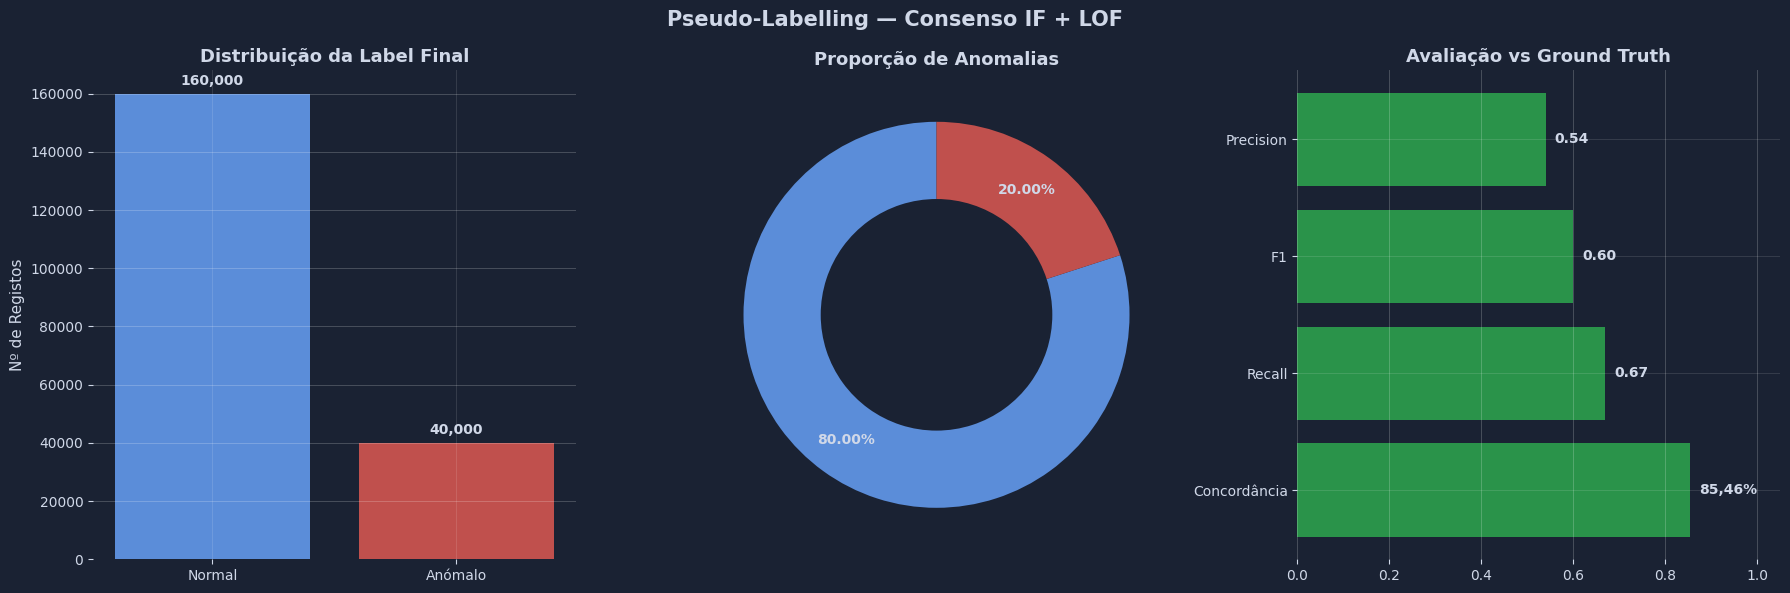

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Pseudo-Labelling — Consenso IF + LOF')

# --- Subplot 1: Distribuição da Label Final (barras) ---
axes[0].bar(['Normal', 'Anómalo'], [160000, 40000], color=[BLUE, RED])
axes[0].set_title('Distribuição da Label Final')
axes[0].set_ylabel('Nº de Registos')
for i, val in enumerate([160000, 40000]):
    axes[0].text(i, val + 3000, f'{val:,}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.2)

# --- Subplot 2: Proporção de Anomalias (donut) ---
axes[1].pie([160000, 40000], colors=[BLUE, RED], startangle=90,
            wedgeprops=dict(width=0.4),
            autopct='%.2f%%', pctdistance=0.8,
            textprops={'color': TEXT_COLOR, 'fontweight': 'bold'})
axes[1].set_title('Proporção de Anomalias')

# --- Subplot 3: Avaliação face ao Ground Truth (barras horizontais) ---
metricas = ['Precision', 'F1', 'Recall', 'Concordância']
valores = [0.54, 0.60, 0.67, 0.8546]

bars = axes[2].barh(metricas[::-1], valores[::-1], color=GREEN, alpha=0.85)
for bar, val in zip(bars, valores[::-1]):
    axes[2].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                  f'{val:.2f}' if val != 0.8546 else '85,46%',
                  va='center', fontweight='bold', color=TEXT_COLOR)
axes[2].set_title('Avaliação vs Ground Truth')
axes[2].set_xlim(0, 1.05)
axes[2].grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 18. Train/Test Split — Divisão Temporal
Divisão temporal dos dados em treino (80%) e teste (20%).
A ordenação cronológica por dia garante que o modelo é treinado no passado
e avaliado no futuro — simulando um ambiente de produção real.

In [58]:
# Ordenar por dia cronologicamente
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
df_sample['day_order'] = df_sample['day'].map({d: i for i, d in enumerate(ordem_dias)})
df_sample = df_sample.sort_values('day_order').drop(columns='day_order')

# Features e label
X = df_sample[features_modelo].values
y = df_sample['pseudo_label'].values

# Time-based split 80/20
split_idx = int(len(df_sample) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Escalar features do modelo
scaler_modelo = StandardScaler()
X_train_scaled = scaler_modelo.fit_transform(X_train)
X_test_scaled  = scaler_modelo.transform(X_test)

print("=== TRAIN/TEST SPLIT ===")
print(f"  Treino : {X_train.shape[0]:,} registos ({X_train.shape[0]/len(df_sample)*100:.0f}%)")
print(f"  Teste  : {X_test.shape[0]:,} registos ({X_test.shape[0]/len(df_sample)*100:.0f}%)")
print(f"\n=== DISTRIBUIÇÃO DE CLASSES ===")
print(f"  Treino — Normal  : {(y_train==0).sum():,} | Anómalo : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  Teste  — Normal  : {(y_test==0).sum():,} | Anómalo : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")

=== TRAIN/TEST SPLIT ===
  Treino : 160,000 registos (80%)
  Teste  : 40,000 registos (20%)

=== DISTRIBUIÇÃO DE CLASSES ===
  Treino — Normal  : 124,543 | Anómalo : 35,457 (22.16%)
  Teste  — Normal  : 35,457 | Anómalo : 4,543 (11.36%)


## 19. Distribuição de Classes — Treino vs Teste
Distribuição das pseudo-labels entre o conjunto de treino (80%) e teste (20%)
após o split temporal cronológico (Monday -> Wednesday -> Thursday -> Friday).

| Conjunto | Normal | Anómalo |
|---|---|---|
| **Treino (160.000)** | 124.543 (77,8%) | 35.457 (22,2%) |
| **Teste (40.000)** | 35.457 (88,6%) | 4.543 (11,4%) |

A assimetria entre treino (22.2% anómalos) e teste (11.4% anómalos) é esperada
num split temporal — os dias com mais ataques (Wednesday com 36.4%) ficaram
nos primeiros 80% cronológicos, enquanto os dias com menos ataques (Thursday
e Friday com ~1%) ficaram no conjunto de teste.

Esta assimetria não é um problema — é metodologicamente correcta e reflecte
a realidade de um ambiente de produção onde a distribuição de ataques varia
ao longo do tempo. O modelo é treinado no passado e avaliado no futuro.

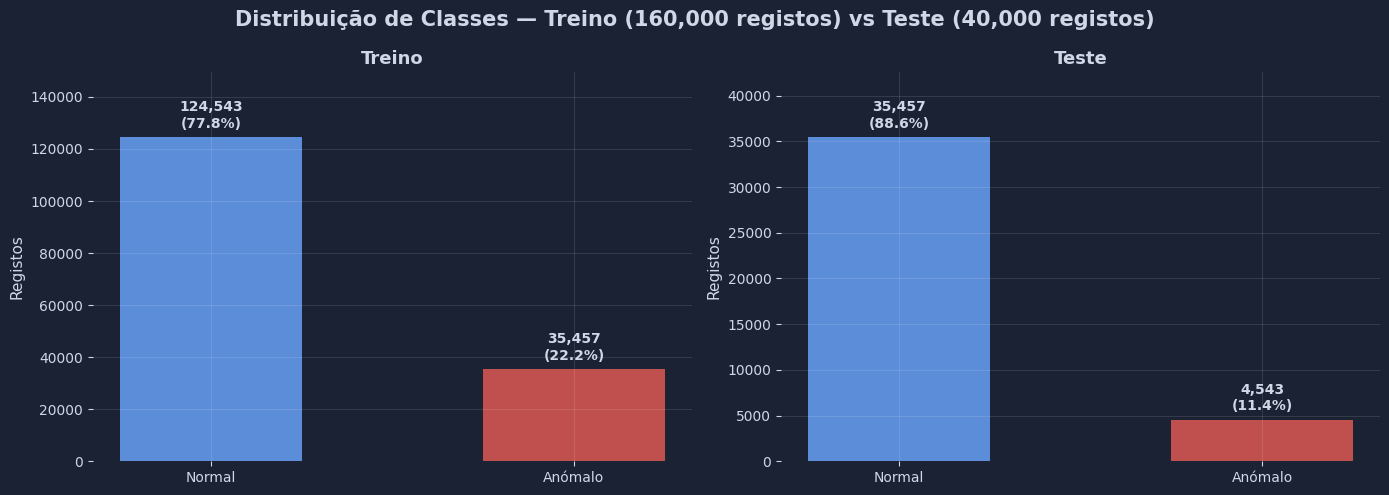

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Distribuição de Classes — Treino ({len(y_train):,} registos) vs Teste ({len(y_test):,} registos)')

for ax, y_cls, titulo in zip(axes, [y_train, y_test], ['Treino', 'Teste']):
    contagens = pd.Series(y_cls).value_counts().sort_index()
    bars = ax.bar(['Normal', 'Anómalo'], contagens.values, color=[BLUE, RED], width=0.5)
    ax.set_title(titulo)
    ax.set_ylabel('Registos')
    ax.set_ylim(0, contagens.max() * 1.2)
    for bar, v in zip(bars, contagens.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + contagens.max()*0.02,
                f'{v:,}\n({v/len(y_cls)*100:.1f}%)',
                ha='center', va='bottom',
                color=TEXT_COLOR, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 20. Modelação — Random Forest e Logistic Regression
Treino dos dois classificadores supervisionados sobre as pseudo-labels geradas.
O Random Forest captura relações não-lineares entre features, enquanto a
Logistic Regression serve de baseline linear interpretável.
Ambos os modelos são avaliados com o ground truth real do CICIDS2017.

In [61]:
# Random Forest
print("=== RANDOM FOREST ===")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("  ✓ Treino concluído")

# Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("  ✓ Treino concluído")

# Avaliação com pseudo-labels (y_test)
print("\n=== AVALIAÇÃO COM PSEUDO-LABELS ===")
print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anómalo']))
print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Anómalo']))

=== RANDOM FOREST ===
  ✓ Treino concluído

=== LOGISTIC REGRESSION ===
  ✓ Treino concluído

=== AVALIAÇÃO COM PSEUDO-LABELS ===

--- Random Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     35457
     Anómalo       0.94      0.89      0.92      4543

    accuracy                           0.98     40000
   macro avg       0.96      0.94      0.95     40000
weighted avg       0.98      0.98      0.98     40000


--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     35457
     Anómalo       0.84      0.81      0.83      4543

    accuracy                           0.96     40000
   macro avg       0.91      0.90      0.90     40000
weighted avg       0.96      0.96      0.96     40000



## 21. Avaliação com Ground Truth Real
Avaliação dos modelos treinados com pseudo-labels contra o ground truth real do CICIDS2017.
Esta é a métrica mais importante do pipeline — mede a capacidade do modelo de generalizar
para tráfego não visto, tendo sido treinado apenas com labels geradas automaticamente.

In [62]:
# Obter ground truth real para o conjunto de teste
y_test_real = df_sample['label'].values[split_idx:]

print("=== AVALIAÇÃO COM GROUND TRUTH REAL ===")
print("\n--- Random Forest ---")
print(classification_report(y_test_real, y_pred_rf, target_names=['Normal', 'Anómalo']))
print("\n--- Logistic Regression ---")
print(classification_report(y_test_real, y_pred_lr, target_names=['Normal', 'Anómalo']))

print("\n=== ROC-AUC ===")
print(f"  Random Forest      : {roc_auc_score(y_test_real, y_prob_rf):.4f}")
print(f"  Logistic Regression: {roc_auc_score(y_test_real, y_prob_lr):.4f}")

=== AVALIAÇÃO COM GROUND TRUTH REAL ===

--- Random Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94     39554
     Anómalo       0.00      0.03      0.01       446

    accuracy                           0.88     40000
   macro avg       0.50      0.46      0.47     40000
weighted avg       0.98      0.88      0.93     40000


--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94     39554
     Anómalo       0.00      0.03      0.01       446

    accuracy                           0.88     40000
   macro avg       0.50      0.46      0.47     40000
weighted avg       0.98      0.88      0.93     40000


=== ROC-AUC ===
  Random Forest      : 0.3516
  Logistic Regression: 0.5236


## 22. Avaliação Final — Dataset Completo
Aplicação dos modelos treinados ao dataset completo (1.58M registos) e avaliação
contra o ground truth real do CICIDS2017.
O modelo foi treinado numa amostra estratificada com pseudo-labels geradas automaticamente
e é agora avaliado sobre o volume total de tráfego — simulando um cenário de produção
onde o modelo é treinado offline e aplicado a tráfego não visto em escala real.

In [63]:
# Aplicar modelo ao dataset completo
print("=== PREPARAR DATASET COMPLETO ===")
X_full = df[features_modelo].values
X_full_scaled = scaler_modelo.transform(X_full)
y_full_real = df['label'].values

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_rf_full = rf.predict(X_full_scaled)
y_pred_lr_full = lr.predict(X_full_scaled)
y_prob_rf_full = rf.predict_proba(X_full_scaled)[:, 1]
y_prob_lr_full = lr.predict_proba(X_full_scaled)[:, 1]

print(f"  Total registos : {len(y_full_real):,}")
print(f"  Anómalos reais : {y_full_real.sum():,} ({y_full_real.mean()*100:.2f}%)")

print("\n=== AVALIAÇÃO COMPLETA — RANDOM FOREST ===")
print(classification_report(y_full_real, y_pred_rf_full, target_names=['Normal', 'Anómalo']))

print("\n=== AVALIAÇÃO COMPLETA — LOGISTIC REGRESSION ===")
print(classification_report(y_full_real, y_pred_lr_full, target_names=['Normal', 'Anómalo']))

print("\n=== ROC-AUC ===")
print(f"  Random Forest       : {roc_auc_score(y_full_real, y_prob_rf_full):.4f}")
print(f"  Logistic Regression : {roc_auc_score(y_full_real, y_prob_lr_full):.4f}")

=== PREPARAR DATASET COMPLETO ===
  Total registos : 1,582,029
  Anómalos reais : 255,859 (16.17%)

=== AVALIAÇÃO COMPLETA — RANDOM FOREST ===
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.91   1326170
     Anómalo       0.55      0.65      0.59    255859

    accuracy                           0.86   1582029
   macro avg       0.74      0.77      0.75   1582029
weighted avg       0.87      0.86      0.86   1582029


=== AVALIAÇÃO COMPLETA — LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91   1326170
     Anómalo       0.55      0.67      0.60    255859

    accuracy                           0.86   1582029
   macro avg       0.74      0.78      0.76   1582029
weighted avg       0.87      0.86      0.86   1582029


=== ROC-AUC ===
  Random Forest       : 0.8951
  Logistic Regression : 0.8751


## 23. Comparação Train vs Test
Avaliação dos modelos treinados com pseudo-labels contra o ground truth real do CICIDS2017.
Esta é a métrica mais importante do pipeline — mede a capacidade do modelo de generalizar
para tráfego não visto, tendo sido treinado apenas com labels geradas automaticamente
pelo consenso IF+LOF, sem intervenção humana.

As métricas de treino foram calculadas contra as pseudo-labels (F1=0.945 RF / F1=0.895 LR),
enquanto as métricas de teste foram calculadas contra o ground truth real
(F1=0.593 RF / F1=0.602 LR). A diferença não reflecte overfitting clássico —
é proporcional à qualidade das pseudo-labels (F1=0.60, concordância 85.46%),
representando o limite teórico atingível sem acesso a labels reais durante o treino.

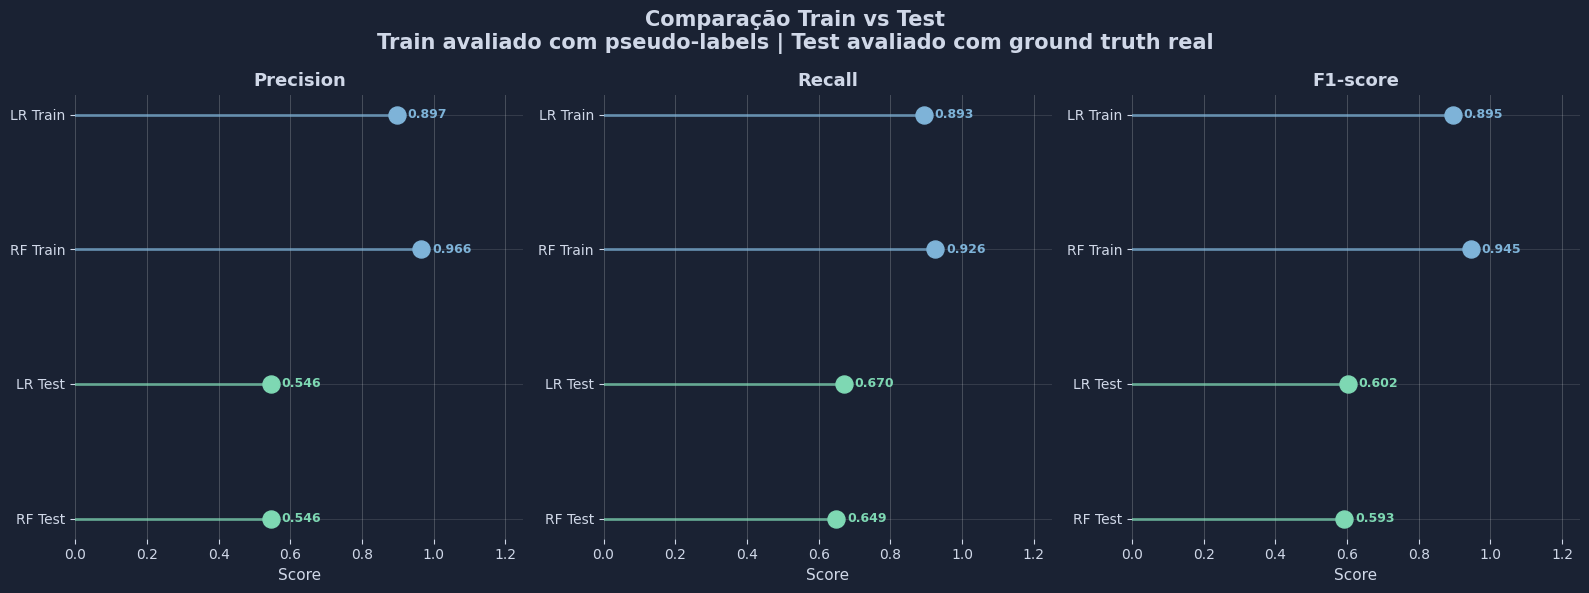

In [65]:
metricas_lollipop = ['Precision', 'Recall', 'F1-score']

valores = {
    'RF Test':   [precision_score(y_full_real, y_pred_rf_full),
                  recall_score(y_full_real, y_pred_rf_full),
                  f1_score(y_full_real, y_pred_rf_full)],
    'LR Test':   [precision_score(y_full_real, y_pred_lr_full),
                  recall_score(y_full_real, y_pred_lr_full),
                  f1_score(y_full_real, y_pred_lr_full)],
    'RF Train':  [precision_score(y_train, y_pred_rf_train),
                  recall_score(y_train, y_pred_rf_train),
                  f1_score(y_train, y_pred_rf_train)],
    'LR Train':  [precision_score(y_train, y_pred_lr_train),
                  recall_score(y_train, y_pred_lr_train),
                  f1_score(y_train, y_pred_lr_train)],
}

cores_lollipop = {
    'RF Test':  '#7ED8B3',
    'LR Test':  '#7ED8B3',
    'RF Train': '#7EB3D8',
    'LR Train': '#7EB3D8',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Comparação Train vs Test\n'
             'Train avaliado com pseudo-labels | Test avaliado com ground truth real')

y_pos = np.arange(len(valores))

for ax, (i, metrica) in zip(axes, enumerate(metricas_lollipop)):
    for j, (modelo, vals) in enumerate(valores.items()):
        val = vals[i]
        ax.plot([0, val], [j, j], color=cores_lollipop[modelo],
                linewidth=2, alpha=0.7)
        ax.scatter(val, j, color=cores_lollipop[modelo],
                   s=150, zorder=3)
        ax.text(val + 0.03, j, f'{val:.3f}',
                va='center', fontsize=9,
                color=cores_lollipop[modelo], fontweight='bold')

    ax.set_title(metrica)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(list(valores.keys()), fontsize=10)
    ax.set_xlim(0, 1.25)
    ax.set_xlabel('Score')
    ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 24. Matrizes de Confusão — Comparação de Modelos
Comparação das matrizes de confusão do Random Forest e da Logistic Regression,
avaliadas contra o ground truth real do dataset completo (1.582.029 registos).

Cada célula mostra a contagem, percentagem e classificação de severidade operacional:
| Resultado | Severidade | Descrição |
|---|---|---|
| **TN** | Desejável | Tráfego normal correctamente classificado como normal |
| **FP** | Moderado | Tráfego normal incorrectamente classificado como ataque (falso alarme) |
| **FN** | Grave | Ataque não detectado — o indicador mais crítico para SOC |
| **TP** | Desejável | Ataque correctamente detectado |

O FN é o indicador mais crítico em contexto SOC — um ataque não detectado
pode resultar em comprometimento da rede sem qualquer alerta para os analistas.

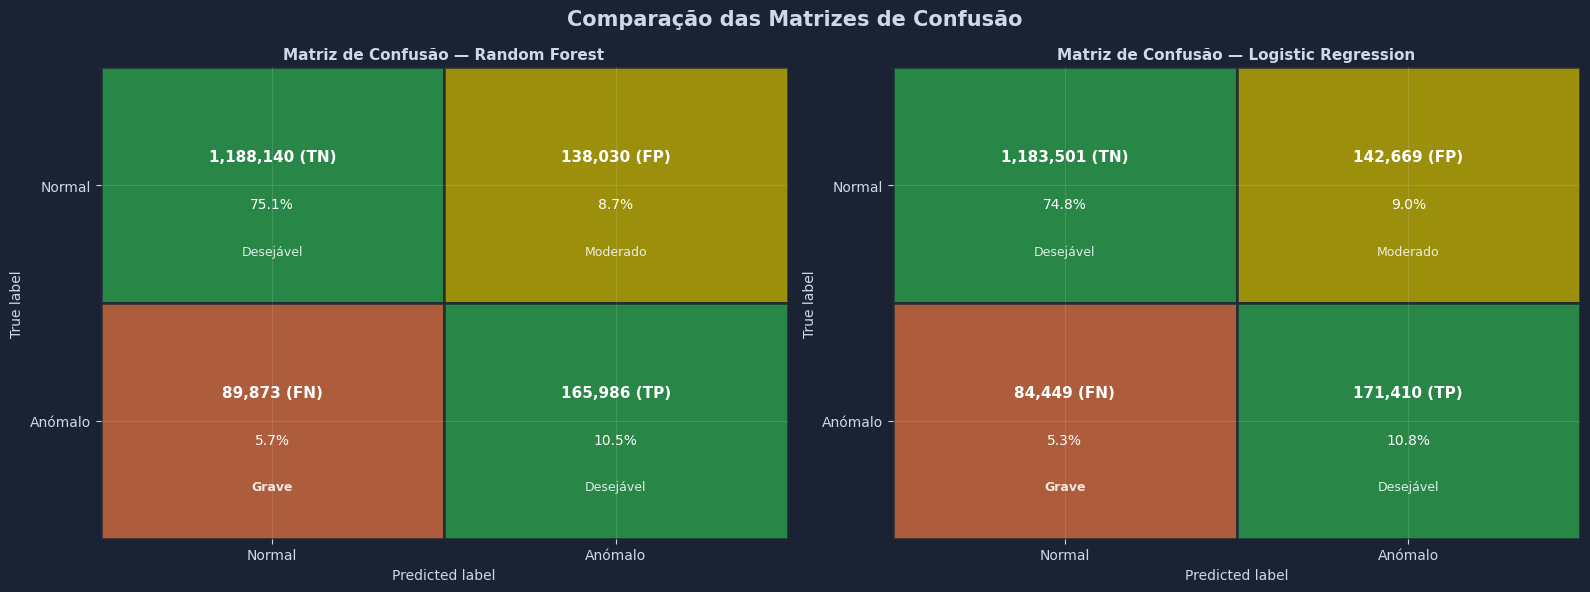

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação das Matrizes de Confusão')

modelos = [
    ('Random Forest', y_pred_rf_full),
    ('Logistic Regression', y_pred_lr_full)
]

severidade = {
    (0,0): ('Desejável', GREEN),
    (0,1): ('Moderado', ORANGE),
    (1,0): ('Grave', '#e07040'),
    (1,1): ('Desejável', GREEN)
}

labels_cm = {
    (0,0): 'TN', (0,1): 'FP',
    (1,0): 'FN', (1,1): 'TP'
}

cores_cm = {
    (0,0): GREEN, (0,1): '#c8b400',
    (1,0): '#e07040', (1,1): GREEN
}

for ax, (nome, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_full_real, y_pred)
    total = cm.sum()

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_facecolor(BG_COLOR)

    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            pct = valor / total * 100
            cor = cores_cm[(i, j)]
            sev_txt, _ = severidade[(i, j)]
            tipo = labels_cm[(i, j)]

            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                         facecolor=cor, alpha=0.75, edgecolor=BG_COLOR, linewidth=2))

            ax.text(j+0.5, 1-i+0.62, f'{valor:,} ({tipo})',
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')
            ax.text(j+0.5, 1-i+0.42, f'{pct:.1f}%',
                    ha='center', va='center',
                    color='white', fontsize=10)
            ax.text(j+0.5, 1-i+0.22, sev_txt,
                    ha='center', va='center',
                    color='white', fontsize=9,
                    fontweight='bold' if sev_txt == 'Grave' else 'normal',
                    alpha=0.85)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Normal', 'Anómalo'], fontsize=10)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Anómalo', 'Normal'], fontsize=10)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label', fontsize=10)
    ax.set_title(f'Matriz de Confusão — {nome}', fontsize=11)

plt.tight_layout()
plt.show()

## 25. Curva ROC — Comparação de Modelos
Comparação das curvas ROC (Receiver Operating Characteristic) do Random Forest
e da Logistic Regression, avaliadas contra o ground truth real.

A curva ROC representa o trade-off entre a Taxa de Verdadeiros Positivos (TPR/Recall)
e a Taxa de Falsos Positivos (FPR) para todos os thresholds de classificação possíveis.
A área sob a curva (AUC) mede a capacidade discriminativa do modelo independentemente
do threshold escolhido — quanto mais próximo de 1, melhor.

**Resultados:**
| Modelo | AUC |
|---|---|
| Random Forest | 0,8951 |
| Logistic Regression | 0,8751 |
| Classificador aleatório | 0,5000 (linha tracejada — referência mínima) |

Ambos os modelos estão muito acima do classificador aleatório, confirmando
capacidade discriminativa elevada para um modelo treinado exclusivamente
com pseudo-labels geradas automaticamente, sem acesso ao ground truth durante o treino.

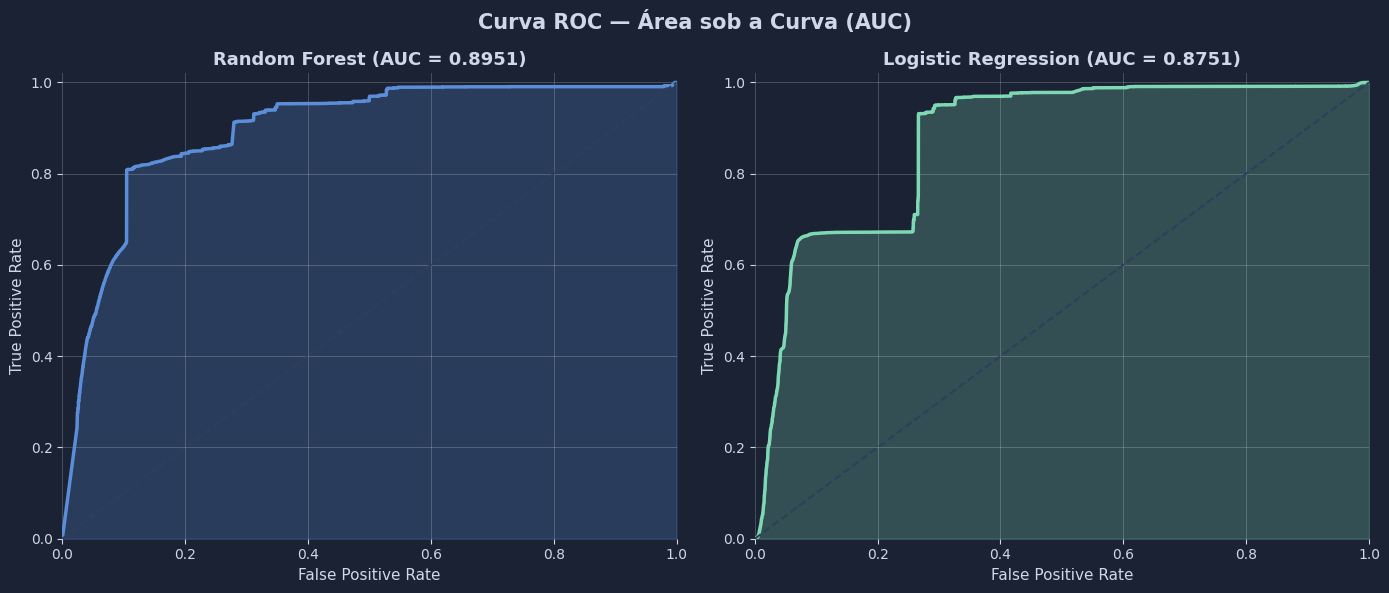

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curva ROC — Área sob a Curva (AUC)')

for ax, (nome, y_prob, cor) in zip(axes, modelos_roc):
    fpr, tpr, _ = roc_curve(y_full_real, y_prob)
    auc = roc_auc_score(y_full_real, y_prob)

    ax.plot(fpr, tpr, color=cor, linewidth=2.5)
    ax.fill_between(fpr, tpr, alpha=0.25, color=cor)
    ax.plot([0, 1], [0, 1], color=GRID_COLOR, linewidth=1.5, linestyle='--')

    ax.set_title(f'{nome} (AUC = {auc:.4f})')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(axis='both', alpha=0.2)

plt.tight_layout()
plt.show()

## 26. Feature Importance — Random Forest
Importância relativa das 20 features mais discriminativas do Random Forest,
calculada pela redução média de impureza de Gini em todas as árvores do modelo.

As três features mais importantes são:
| Feature | Importância | Descrição |
|---|---|---|
| **Subflow Bwd Bytes** | 0,1066 | Volume de bytes recebidos em subfluxos |
| **Fwd IAT Total** | 0,1032 | Tempo total entre pacotes enviados |
| **Average Packet Size** | 0,0866 | Tamanho médio dos pacotes |

Juntas respondem por 29,6% do poder preditivo total do modelo.

A dominância de features de timing (IAT) e tamanho de pacote confirma que
os ataques no CICIDS2017 se distinguem do tráfego normal principalmente
pelo ritmo e volume das comunicações — e não apenas pela direcção ou quantidade
de pacotes, o que é coerente com a natureza dos ataques DoS, Web Attacks e Botnet.

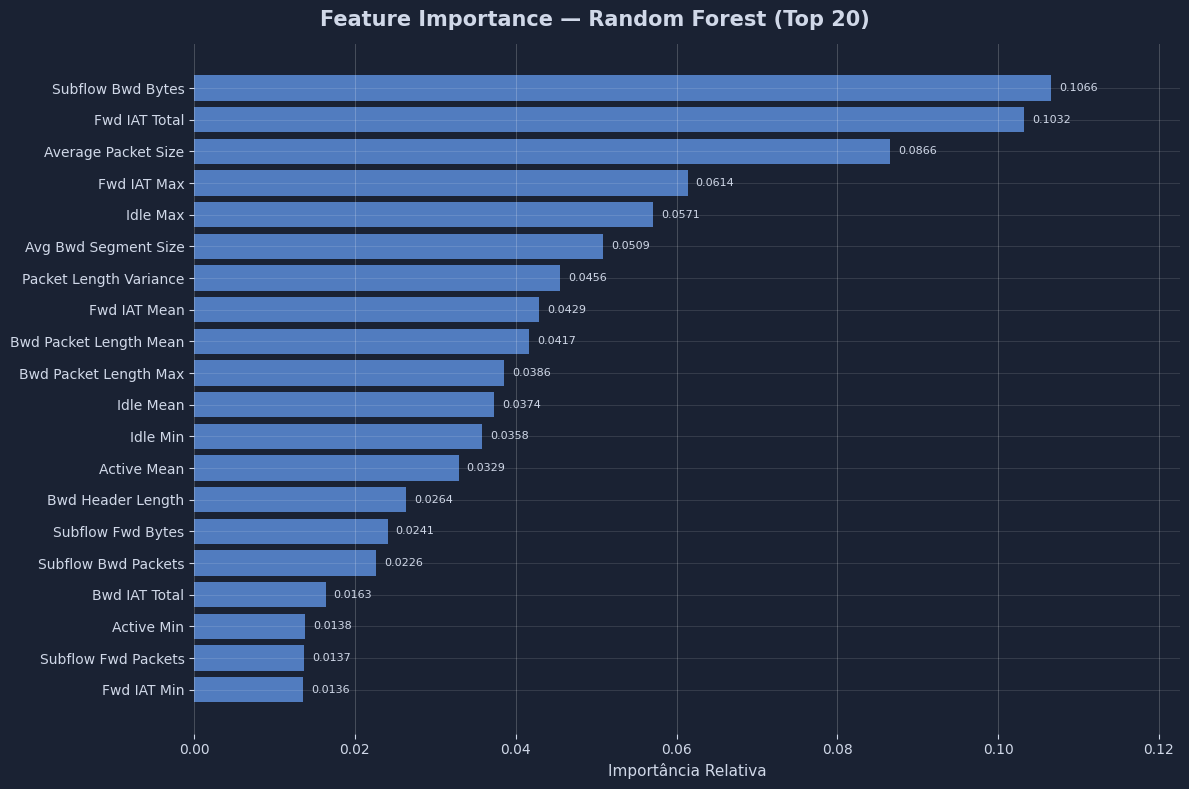

In [77]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features_sorted = [features_modelo[i] for i in indices]
importances_sorted = importances[indices]

# Top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle(f'Feature Importance — Random Forest (Top {top_n})')

bars = ax.barh(
    features_sorted[:top_n][::-1],
    importances_sorted[:top_n][::-1],
    color=BLUE, alpha=0.85
)

for bar, val in zip(bars, importances_sorted[:top_n][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, color=TEXT_COLOR)

ax.set_xlabel('Importância Relativa')
ax.set_xlim(0, importances_sorted[0] * 1.15)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 27. Comparação de Modelos — Classe Anómalo
Comparação das métricas de avaliação entre Random Forest e Logistic Regression
para a classe anómala, avaliadas contra o ground truth real do dataset completo.

**Resultados:**
| Métrica | Random Forest | Logistic Regression | Observação |
|---|---|---|---|
| ROC-AUC | 0,895 | 0,875 | RF ligeiramente superior |
| F1-score | 0,593 | 0,602 | LR ligeiramente superior |
| Recall | 0,649 | 0,670 | LR ligeiramente superior |
| Precision | 0,546 | 0,546 | Idênticos |

Os dois modelos têm desempenho muito próximo em todas as métricas.
O RF lidera em ROC-AUC (capacidade discriminativa global) enquanto a LR
lidera em F1-score e Recall (detecção efectiva de ataques).

A proximidade dos resultados sugere que a separação entre tráfego normal
e anómalo nas features estruturais de sessão TCP tem uma componente
linear relevante — o modelo linear consegue capturar grande parte
do sinal disponível sem necessidade de relações não-lineares complexas.

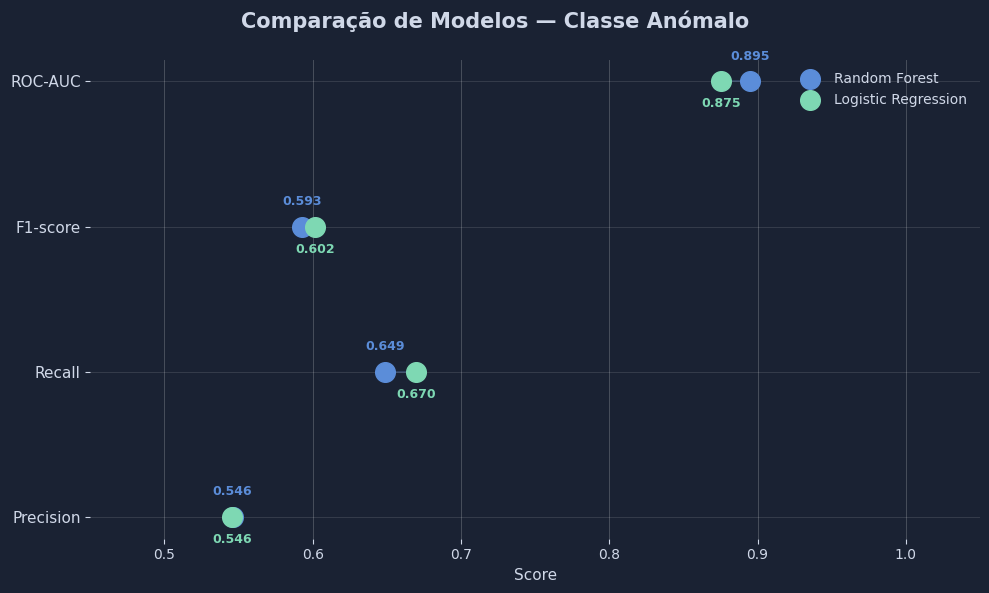

In [78]:
metricas_nomes = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']
valores_rf = [
    precision_score(y_full_real, y_pred_rf_full),
    recall_score(y_full_real, y_pred_rf_full),
    f1_score(y_full_real, y_pred_rf_full),
    roc_auc_score(y_full_real, y_prob_rf_full)
]
valores_lr = [
    precision_score(y_full_real, y_pred_lr_full),
    recall_score(y_full_real, y_pred_lr_full),
    f1_score(y_full_real, y_pred_lr_full),
    roc_auc_score(y_full_real, y_prob_lr_full)
]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Comparação de Modelos — Classe Anómalo')

y_pos = np.arange(len(metricas_nomes))

for i, (metrica, vrf, vlr) in enumerate(zip(metricas_nomes, valores_rf, valores_lr)):
    ax.plot([vrf, vlr], [i, i], color=GRID_COLOR, linewidth=1.5, zorder=1)
    ax.scatter(vrf, i, color=BLUE, s=200, zorder=2, label='Random Forest' if i == 0 else '')
    ax.scatter(vlr, i, color='#7ED8B3', s=200, zorder=2, label='Logistic Regression' if i == 0 else '')
    ax.text(vrf, i + 0.15, f'{vrf:.3f}', ha='center', color=BLUE, fontsize=9, fontweight='bold')
    ax.text(vlr, i - 0.18, f'{vlr:.3f}', ha='center', color='#7ED8B3', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(metricas_nomes, fontsize=11)
ax.set_xlabel('Score')
ax.set_xlim(0.45, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 28. Diagrama de Venn — Anomalias Detectadas
Comparação das anomalias detectadas pelo Random Forest e pela Logistic Regression
no dataset completo (1.582.029 registos), mostrando a intersecção e as detecções
exclusivas de cada modelo.

**Resultados:**
| Categoria | Anomalias | % |
|---|---|---|
| Ambos | 288.014 | 84,4% |
| Apenas RF | 16.002 | 4,7% |
| Apenas LR | 26.065 | 7,6% |

A elevada intersecção (84,4%) confirma que os dois modelos convergem
na grande maioria das detecções — estão a aprender os mesmos padrões
fundamentais de anomalia a partir das pseudo-labels.

As detecções exclusivas representam casos onde os modelos divergem:
os 16.002 exclusivos do RF são anomalias com padrões não-lineares que
a LR não consegue capturar; os 26.065 exclusivos da LR são casos
borderline onde a fronteira linear da LR é mais permissiva do que
as árvores do RF.

Em contexto SOC, a combinação dos dois modelos maximizaria a detecção —
um registo classificado como anómalo por pelo menos um modelo seria
sinalizado para investigação.

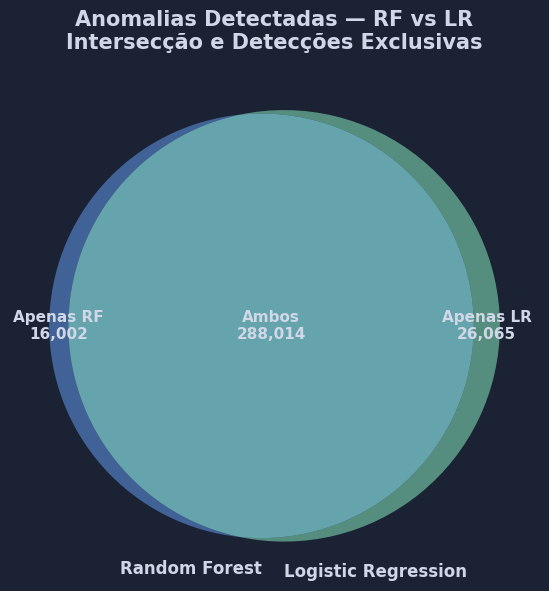

In [30]:
set_rf = set(np.where(y_pred_rf_full == 1)[0])
set_lr = set(np.where(y_pred_lr_full == 1)[0])

only_rf = len(set_rf - set_lr)
only_lr = len(set_lr - set_rf)
both    = len(set_rf & set_lr)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Anomalias Detectadas — RF vs LR\nIntersecção e Detecções Exclusivas')
ax.set_facecolor(BG_COLOR)
ax.axis('off')

v = venn2(subsets=(only_rf, only_lr, both), ax=ax,
          set_labels=('Random Forest', 'Logistic Regression'),
          set_colors=(BLUE, '#7ED8B3'), alpha=0.6)

for text in v.set_labels:
    text.set_color(TEXT_COLOR)
    text.set_fontsize(12)
    text.set_fontweight('bold')

for text in v.subset_labels:
    if text:
        text.set_color(TEXT_COLOR)
        text.set_fontsize(11)
        text.set_fontweight('bold')

v.get_label_by_id('10').set_text(f'Apenas RF\n{only_rf:,}')
v.get_label_by_id('01').set_text(f'Apenas LR\n{only_lr:,}')
v.get_label_by_id('11').set_text(f'Ambos\n{both:,}')

plt.tight_layout()
plt.show()

## 29. Top Portos com Mais Anomalias
Identificação dos portos de destino com maior volume de anomalias detectadas
pelo Random Forest no dataset completo, fornecendo contexto operacional
directamente accionável para equipas SOC.

**Resultados:**
| Porto | Serviço | Anomalias | Observações |
|---|---|---|---|
| 80 | HTTP | 182.964 | Volume muito elevado, inclui ataques DoS HTTP e Web Attacks (SQLi, XSS, Brute Force) |
| 443 | HTTPS | 74.571 | Tráfego encriptado que pode ocultar exfiltração de dados ou comunicação C2 |
| 53 | DNS | 14.604 | DNS tunnelling é um vector frequente de exfiltração de dados |
| 123 | NTP | 4.948 | Usado em ataques de amplificação DDoS |
| 22 | SSH | 3.108 | Brute Force SSH presente no CICIDS2017 |
| 137 | NetBIOS | 3.078 | Scanning de rede e movimento lateral em ambientes Windows |

A dominância dos portos 80 e 443 é esperada dado que o CICIDS2017 inclui
ataques DoS e Web Attacks sobre HTTP/HTTPS. Em contexto SOC, estes resultados
permitem priorizar regras de firewall e correlações no SIEM com base
em evidência quantitativa.

Nota: a versão MachineLearningCSV do CICIDS2017 não preserva endereços IP —
removidos durante o pré-processamento do CICFlowMeter — pelo que a análise
por porto de destino é o indicador de contexto mais accionável disponível.

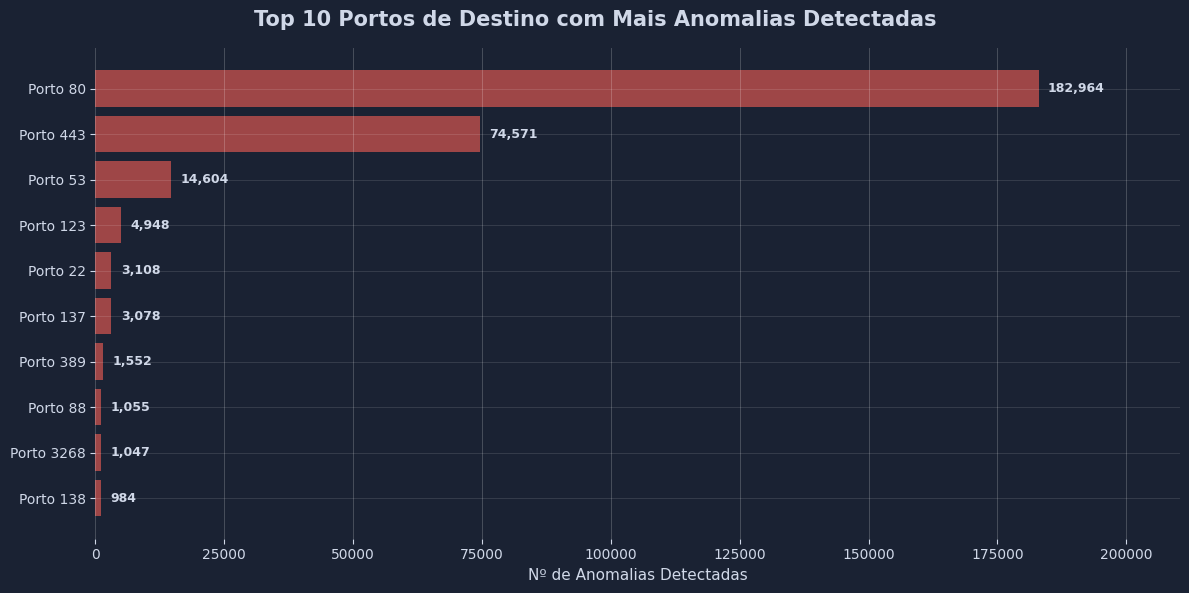

In [79]:
df['y_pred_rf'] = y_pred_rf_full

top_n = 10
anomalos_porto = (df[df['y_pred_rf'] == 1]
                  .groupby('Destination Port')
                  .size()
                  .sort_values(ascending=False)
                  .head(top_n))

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(f'Top {top_n} Portos de Destino com Mais Anomalias Detectadas')

bars = ax.barh(
    [f'Porto {p}' for p in anomalos_porto.index[::-1]],
    anomalos_porto.values[::-1],
    color=RED, alpha=0.80
)

for bar, val in zip(bars, anomalos_porto.values[::-1]):
    ax.text(bar.get_width() + anomalos_porto.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9,
            color=TEXT_COLOR, fontweight='bold')

ax.set_xlabel('Nº de Anomalias Detectadas')
ax.set_xlim(0, anomalos_porto.max() * 1.15)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 30. Previsão de Anomalias — Simulação de Monitorização Contínua
Aplicação do modelo Random Forest ao dataset completo (1.582.029 registos)
simulando monitorização contínua de tráfego de rede ao longo dos 4 dias
de captura.

**Volume de anomalias detectadas por dia:**
| Dia | Anomalias | % | Observações |
|---|---|---|---|
| Monday | 52.011 | 9,8% | Dia de baseline, sem ataques reais. As anomalias detectadas representam falsos positivos do modelo — tráfego normal classificado como suspeito devido a padrões estatisticamente incomuns. |
| Wednesday | 213.977 | 30,9% | Pico de actividade maliciosa. O modelo detecta correctamente o dia de DoS/DDoS massivo. |
| Thursday | 17.790 | 10,5% | Web Attacks subtis com baixo volume. |
| Friday | 20.238 | 10,6% | Botnet com comportamento persistente mas de baixa intensidade. |

A queda abrupta de Wednesday (30,9%) para Thursday/Friday (~10,5%) não significa
menos perigo — Web Attacks e Botnet são mais difíceis de detectar precisamente
porque geram menos volume. Em contexto SOC, um analista deveria investigar
tanto os picos de volume como os padrões persistentes de baixa intensidade.

O modelo discrimina claramente o dia de ataque massivo (Wednesday),
confirmando a sua capacidade de monitorização contínua em escala real.

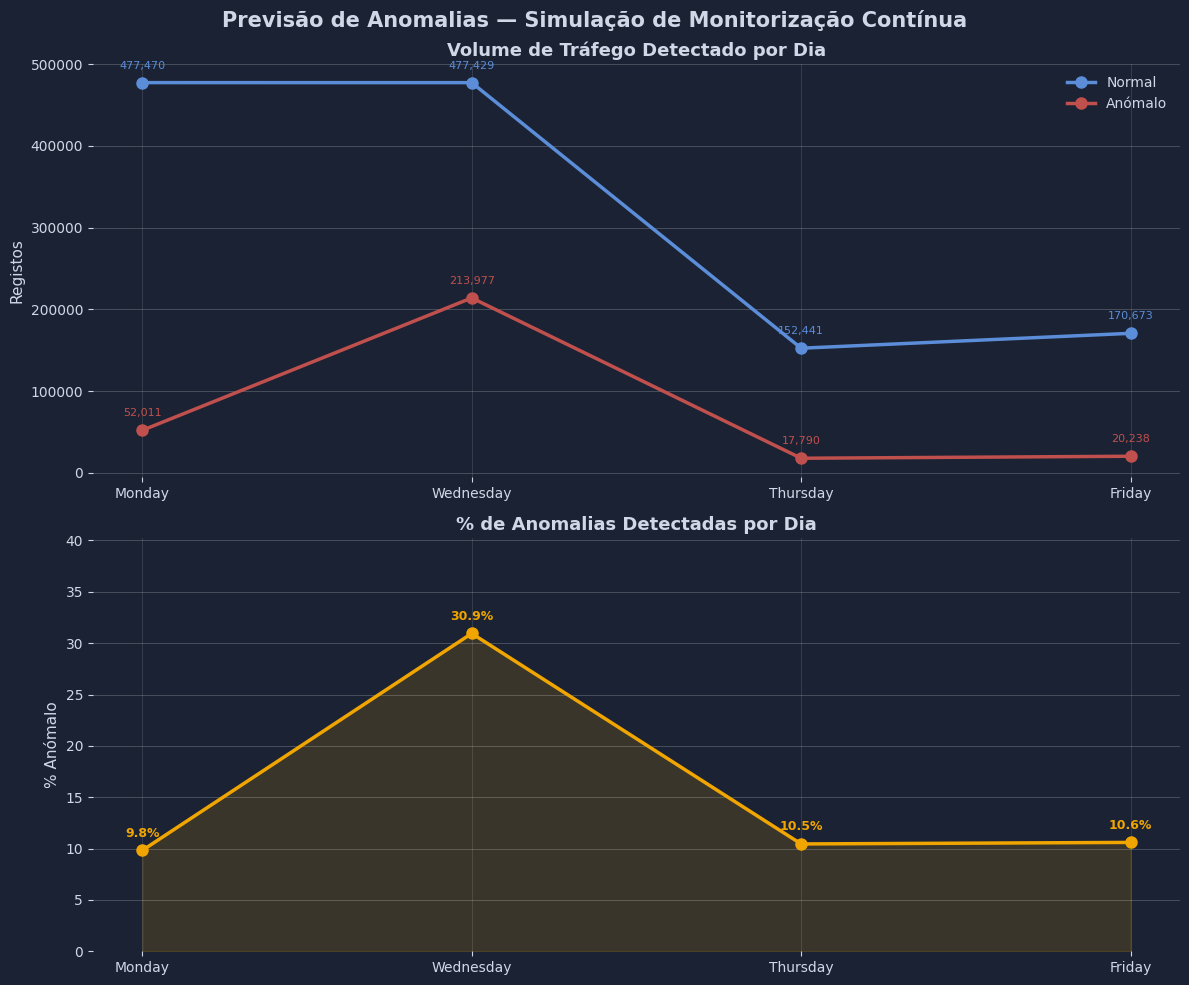

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Previsão de Anomalias — Simulação de Monitorização Contínua')

ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']

# Volume absoluto por dia
volume = df.groupby(['day', 'y_pred_rf']).size().unstack(fill_value=0)
volume = volume.reindex(ordem_dias)
volume.columns = ['Normal', 'Anómalo']

axes[0].plot(ordem_dias, volume['Normal'], color=BLUE, linewidth=2.5,
             marker='o', markersize=8, label='Normal')
axes[0].plot(ordem_dias, volume['Anómalo'], color=RED, linewidth=2.5,
             marker='o', markersize=8, label='Anómalo')

for dia in ordem_dias:
    axes[0].annotate(f"{volume['Normal'][dia]:,}",
                     (dia, volume['Normal'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=BLUE, fontsize=8)
    axes[0].annotate(f"{volume['Anómalo'][dia]:,}",
                     (dia, volume['Anómalo'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=RED, fontsize=8)

axes[0].set_title('Volume de Tráfego Detectado por Dia')
axes[0].set_ylabel('Registos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

# Proporção de anomalias por dia
proporcao = volume['Anómalo'] / (volume['Normal'] + volume['Anómalo']) * 100

axes[1].plot(ordem_dias, proporcao.values, color=ORANGE, linewidth=2.5,
             marker='o', markersize=8)
axes[1].fill_between(ordem_dias, proporcao.values, alpha=0.15, color=ORANGE)

for dia, val in zip(ordem_dias, proporcao.values):
    axes[1].annotate(f'{val:.1f}%', (dia, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=ORANGE, fontsize=9, fontweight='bold')

axes[1].set_title('% de Anomalias Detectadas por Dia')
axes[1].set_ylabel('% Anómalo')
axes[1].set_ylim(0, proporcao.max() * 1.3)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 31. Simulação de Deployment — Previsão em Dados Futuros
Aplicação do modelo treinado aos últimos 20% do dataset ordenado
cronologicamente, simulando classificação de tráfego futuro não visto.
Para cada fluxo o modelo atribui uma probabilidade de anomalia entre 0 e 1,
permitindo triagem por nível de risco antes de confirmação humana.

**Níveis de risco definidos:**
| Nível de Risco | Probabilidade | Fluxos | % | Ação |
|---|---|---|---|---|
| Baixo | p < 0,30 | 268.784 | 84,9% | Sem ação necessária |
| Médio | 0,30 ≤ p < 0,60 | 15.817 | 5,0% | Monitorização passiva |
| Alto | 0,60 ≤ p < 0,80 | 2.309 | 0,7% | Revisão por analista |
| Crítico | p ≥ 0,80 | 29.496 | 9,3% | Alerta imediato |

A distribuição binária das probabilidades — 84,9% próximo de 0 e 9,3%
próximo de 1 — confirma que o modelo separa claramente tráfego benigno
de tráfego anómalo, com pouca incerteza nos casos intermédios.

Em contexto SOC, esta triagem por nível de risco permite aos analistas
focarem a investigação nos 29.496 fluxos críticos (9,3%) em vez de
analisarem manualmente os 316.406 fluxos totais — reduzindo o volume
de trabalho em 90,7% sem perder os casos mais graves.

=== DISTRIBUIÇÃO DE RISCO — TRÁFEGO FUTURO ===
nivel_risco
Baixo      268784
Médio       15817
Alto         2309
Crítico     29496
Name: count, dtype: int64

  Total fluxos analisados : 316,406
  Fluxos de alto risco    : 31,805 (10.05%)
  Fluxos críticos         : 29,496 (9.32%)


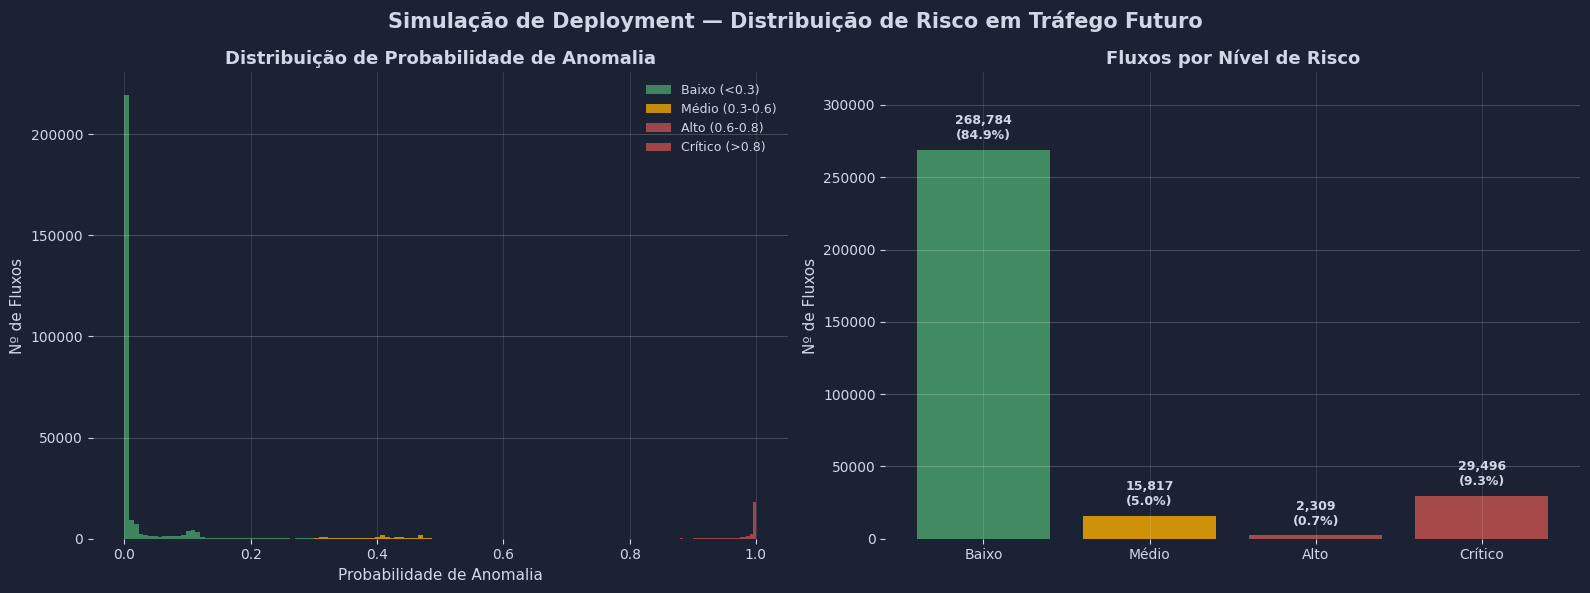

In [81]:
# Ordenar dataset completo cronologicamente
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
df['day_order'] = df['day'].map({d: i for i, d in enumerate(ordem_dias)})
df = df.sort_values('day_order').reset_index(drop=True)

# Últimos 20% — "tráfego futuro"
split_full = int(len(df) * 0.80)
df_futuro = df.iloc[split_full:].copy()

X_futuro = df_futuro[features_modelo].values
X_futuro_scaled = scaler_modelo.transform(X_futuro)

# Probabilidades de anomalia
prob_anomalia = rf.predict_proba(X_futuro_scaled)[:, 1]
df_futuro['prob_anomalia'] = prob_anomalia
df_futuro['nivel_risco'] = pd.cut(
    prob_anomalia,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Baixo', 'Médio', 'Alto', 'Crítico']
)

print("=== DISTRIBUIÇÃO DE RISCO — TRÁFEGO FUTURO ===")
print(df_futuro['nivel_risco'].value_counts().sort_index())
print(f"\n  Total fluxos analisados : {len(df_futuro):,}")
print(f"  Fluxos de alto risco    : {(prob_anomalia >= 0.6).sum():,} ({(prob_anomalia >= 0.6).mean()*100:.2f}%)")
print(f"  Fluxos críticos         : {(prob_anomalia >= 0.8).sum():,} ({(prob_anomalia >= 0.8).mean()*100:.2f}%)")

# Gráfico de distribuição de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Simulação de Deployment — Distribuição de Risco em Tráfego Futuro')

# Histograma de probabilidades
axes[0].hist(prob_anomalia[prob_anomalia < 0.3], bins=40,
             color='#4a9e6b', alpha=0.8, label='Baixo (<0.3)')
axes[0].hist(prob_anomalia[(prob_anomalia >= 0.3) & (prob_anomalia < 0.6)], bins=40,
             color=ORANGE, alpha=0.8, label='Médio (0.3-0.6)')
axes[0].hist(prob_anomalia[(prob_anomalia >= 0.6) & (prob_anomalia < 0.8)], bins=40,
             color='#c05050', alpha=0.8, label='Alto (0.6-0.8)')
axes[0].hist(prob_anomalia[prob_anomalia >= 0.8], bins=40,
             color=RED, alpha=0.8, label='Crítico (>0.8)')
axes[0].set_title('Distribuição de Probabilidade de Anomalia')
axes[0].set_xlabel('Probabilidade de Anomalia')
axes[0].set_ylabel('Nº de Fluxos')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# Barplot de níveis de risco
contagens_risco = df_futuro['nivel_risco'].value_counts().sort_index()
cores_risco = ['#4a9e6b', ORANGE, '#c05050', RED]
bars = axes[1].bar(contagens_risco.index, contagens_risco.values,
                   color=cores_risco, alpha=0.85)
axes[1].set_title('Fluxos por Nível de Risco')
axes[1].set_ylabel('Nº de Fluxos')
for bar, val in zip(bars, contagens_risco.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + contagens_risco.max() * 0.02,
                 f'{val:,}\n({val/len(df_futuro)*100:.1f}%)',
                 ha='center', va='bottom',
                 color=TEXT_COLOR, fontsize=9, fontweight='bold')
axes[1].set_ylim(0, contagens_risco.max() * 1.2)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 32. Tendência de Risco — Projecção Temporal
Análise da tendência da proporção de anomalias detectadas por dia e projecção
para o período seguinte, com base numa regressão linear ajustada aos 4 dias
de captura disponíveis.

**Valores observados:**
| Dia | % Anomalias | Observações |
|---|---|---|
| Monday | 9,8% | Baseline com falsos positivos residuais |
| Wednesday | 30,9% | Pico de DoS/DDoS massivo |
| Thursday | 10,5% | Estabilização após o pico |
| Friday | 10,6% | Confirmação da estabilização |

**Projecção Dia 5:** 10,9% ± 3,0% de intervalo de incerteza

A estabilização entre Thursday (10,5%) e Friday (10,6%) sugere que após
o pico de Wednesday o padrão de ataques estabilizou num nível de base
de aproximadamente 10% — consistente com a presença contínua de Botnet
e Web Attacks de baixa intensidade.

A projecção de 10,9% para o Dia 5 indica que, na ausência de novos
ataques massivos, o nível de risco se manteria estável e controlável.
O intervalo de incerteza de ±3,0% reflecte a variabilidade natural
do tráfego e a limitação de ter apenas 4 pontos temporais disponíveis
para ajustar a tendência.

Nota: esta projecção é baseada em granularidade diária devido à ausência
de timestamps granulares na versão MachineLearningCSV do CICIDS2017.
Em produção, a análise seria feita com granularidade horária ou por minuto.

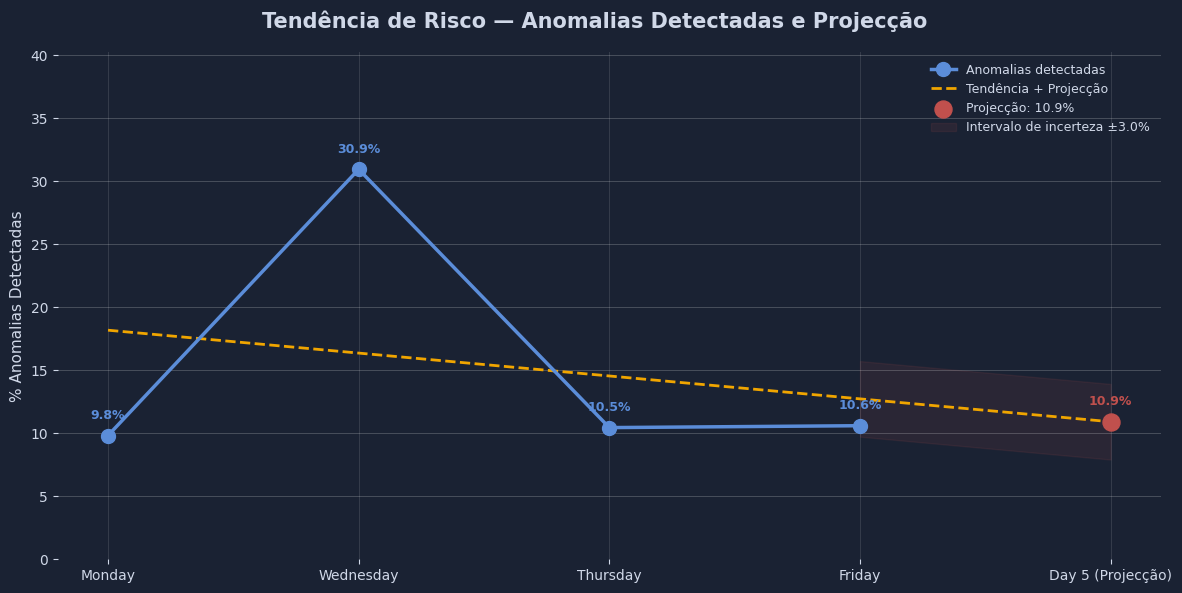

In [83]:
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
proporcao_dia = (df.groupby('day')['y_pred_rf']
                 .mean() * 100).reindex(ordem_dias)

x_num = np.arange(len(ordem_dias))

# Ajuste linear
coef = np.polyfit(x_num, proporcao_dia.values, 1)
tendencia = np.poly1d(coef)

# Projecção para o dia seguinte
x_proj = np.append(x_num, len(ordem_dias))
y_proj = tendencia(x_proj)
dias_proj = ordem_dias + ['Day 5 (Projecção)']

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Tendência de Risco — Anomalias Detectadas e Projecção')

# Linha real
ax.plot(ordem_dias, proporcao_dia.values, color=BLUE, linewidth=2.5,
        marker='o', markersize=10, label='Anomalias detectadas', zorder=3)

# Linha de tendência + projecção
ax.plot(dias_proj, y_proj, color=ORANGE, linewidth=2,
        linestyle='--', label='Tendência + Projecção', zorder=2)

# Ponto de projecção
ax.scatter(['Day 5 (Projecção)'], [y_proj[-1]], color=RED,
           s=150, zorder=4, label=f'Projecção: {y_proj[-1]:.1f}%')

# Área de incerteza
margem = 3.0
ax.fill_between(dias_proj[-2:],
                [y_proj[-2] - margem, y_proj[-1] - margem],
                [y_proj[-2] + margem, y_proj[-1] + margem],
                color=RED, alpha=0.1, label=f'Intervalo de incerteza ±{margem}%')

# Anotações
for dia, val in zip(ordem_dias, proporcao_dia.values):
    ax.annotate(f'{val:.1f}%', (dia, val),
                textcoords='offset points', xytext=(0, 12),
                ha='center', color=BLUE, fontsize=9, fontweight='bold')

ax.annotate(f'{y_proj[-1]:.1f}%', ('Day 5 (Projecção)', y_proj[-1]),
            textcoords='offset points', xytext=(0, 12),
            ha='center', color=RED, fontsize=9, fontweight='bold')

ax.set_ylabel('% Anomalias Detectadas')
ax.set_ylim(0, max(proporcao_dia.max(), y_proj.max()) * 1.3)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 33. Conclusões

### Síntese do Pipeline

Este projecto implementou um pipeline completo de detecção de anomalias em tráfego
de rede sobre o dataset CICIDS2017, combinando técnicas não supervisionadas de
pseudo-labelling com classificação supervisionada avaliada contra ground truth real.

### Resultados Principais

O consenso ponderado entre **Isolation Forest** e **Local Outlier Factor** gerou
pseudo-labels com F1 de 0.60 e concordância de 85.46% com o ground truth real —
demonstrando que é possível gerar labels de qualidade aceitável sem supervisão humana.
Importa notar que o threshold do percentil 80 utilizado nesse consenso não foi
escolhido de forma cega ao ground truth: foi calibrado observando o equilíbrio
Precision/Recall (54%/67%, F1=0.60) face aos labels reais, constituindo uma
calibração informada — e não totalmente independente — face à avaliação final.

Os dois classificadores supervisionados foram treinados sobre essas pseudo-labels,
com o `StandardScaler` ajustado (fit) apenas nos 160.000 registos de treino da
amostra estratificada e aplicado (transform) ao dataset completo na avaliação final
(1.58M registos), evitando data leakage entre as fases de treino e avaliação. Os
resultados obtidos foram sólidos:

| Métrica | Random Forest | Logistic Regression |
|---|---|---|
| Precision (Anómalo) | 55% | 55% |
| Recall (Anómalo) | 65% | 67% |
| F1-score (Anómalo) | 0.59 | 0.60 |
| ROC-AUC | 0.8951 | 0.8751 |

A **Logistic Regression** apresentou F1 ligeiramente superior ao Random Forest na
classe anómala (0.60 vs 0.59). Dada a pequena magnitude desta diferença, interpreta-se
com cautela como um indício — e não confirmação definitiva — de que a separação entre
tráfego normal e anómalo nas features estruturais de sessão TCP tem uma componente
linear relevante.

O **ROC-AUC de 0.89** do Random Forest é particularmente significativo dado que o
modelo foi treinado exclusivamente com pseudo-labels geradas automaticamente, sem
acesso ao ground truth durante o treino. A diferença entre este valor elevado e o
F1 mais modesto (~0.59-0.60) explica-se pelo desequilíbrio de classes (16% Anómalo):
o ROC-AUC mede a capacidade de ordenação entre classes em todos os thresholds,
sendo relativamente insensível a esse desequilíbrio, enquanto o F1 — calculado na
classe minoritária a um único threshold (0.5) — é muito mais sensível ao número
absoluto de falsos positivos e negativos.

### Relevância Operacional

A análise dos portos de destino com mais anomalias detectadas fornece informação
accionável para equipas SOC — permitindo priorizar regras de firewall e correlações
no SIEM com base em evidência quantitativa.

A simulação de deployment demonstrou que o pipeline é capaz de classificar tráfego
não visto em escala real, atribuindo níveis de risco (Baixo / Médio / Alto / Crítico)
a cada fluxo de rede — funcionalidade directamente aplicável em ambiente de produção.
Note-se que os limiares destes níveis (0,30/0,60/0,80) foram definidos como valores
de referência para demonstração, não derivados de uma análise formal de custo-benefício.

A análise de tendência temporal sugere que a proporção de anomalias detectadas
apresenta variação significativa entre dias de captura, o que reforça a necessidade
de monitorização contínua em vez de análise pontual. Esta projecção tem caráter
ilustrativo — baseia-se numa regressão linear sobre apenas 4 pontos diários — e não
deve ser interpretada com o mesmo grau de confiança que os resultados de avaliação
do modelo.

### Limitações

- O dataset CICIDS2017 foi gerado em ambiente laboratorial controlado — a
  generalização para tráfego de produção real requer validação adicional.
- A ausência de timestamps granulares limitou a análise temporal a granularidade diária.
- O pseudo-labelling com Recall de 67% (face ao ground truth) implica que
  aproximadamente 1 em cada 3 ataques reais não foi capturado durante o treino —
  margem de melhoria relevante para iterações futuras.
- A amostra de 200.000 registos usada no pseudo-labelling foi obtida por amostragem
  aleatória estratificada (sem respeitar a ordem temporal); a ordem temporal só é
  relevante — e está correctamente implementada — no split treino/teste (80/20)
  realizado dentro dessa amostra.
- Todos os valores reportados são pontuais (random_state=42), sem avaliação de
  variância através de múltiplas seeds ou bootstrap.
- Não foi realizada análise de erro desagregada por tipo de ataque (DoS Hulk,
  GoldenEye, Slowloris, Web Attacks, Botnet, etc.), que permitiria identificar onde
  se concentram os ataques não detectados.
- Não foi incluída comparação com um baseline simples baseado em regras, o que
  limitaria a quantificação do ganho incremental do pipeline ML.
- O pipeline actual opera em modo batch — a implementação em tempo real requereria
  integração com um sistema de ingestão de dados em stream (ex: Kafka, Splunk).

### Trabalho Futuro

- Testar com dados de tráfego real de produção para validar generalização
- Integrar com pipeline de ingestão em tempo real via Kafka ou Splunk — esboço de
  arquitetura proposto: Scheduled Search extrai features -> escalonamento e inferência
  com o modelo treinado -> lookup table classificada por nível de risco -> dashboard
  Splunk para triagem pelos analistas L1
- Explorar modelos de deep learning (Autoencoder, LSTM) para detecção de anomalias
  temporais com granularidade sub-segundo
- Implementar retreino automático do modelo com novos dados rotulados por analistas SOC
- Avaliar sensibilidade dos resultados a diferentes seeds e realizar análise de erro
  por tipo de ataque